# Organización de datos
---
## <center> Trabajo Práctico 1

### <center> 2 - Modelos de Clasificación Binaria

#### Grupo 05
| Integrante | Padron |
| :--- | :---: |
| Javier Zardain | 102521 |
| Bruno Pezman | 110457  |
| Malena Sein | 112295 |
| Candela Piccin | 109760 |
| Alexis Maximiliano Torres Vargas | 111449 |


# Introduccion
En Australia se desea predecir, dados unos datos meteorologicos del dia de hoy obtenidas por estaciones meteorologicas ubicadas en distintas ciudades, si el dia de mañana llovera, para que su poblacion se pueda anticipar a este acontecimiento y decidir que hacer.  
A nuestro equipo se le ha asignado los siguientes estados:
- Queensland
- Victoria
- Australia Meridional
- Australia Occidental  

Por lo tanto, nuestro objetivo es, dado unos datos climaticos sobre hoy, predecir si mañana llovera o no, asi que como nuestra variable dependiente es cualitativa y con dos posibilidades, estamos ante un problema de clasificacion binaria.


# Preparación

## Incorporacion de bibliotecas a utilizar  

Primero que todo, incorporamos las bibliotecas que utilizaremos a lo largo de este trabajo.

In [287]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score,f1_score,confusion_matrix,RocCurveDisplay
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

import kagglehub
from kagglehub import KaggleDatasetAdapter

import os
import joblib


## Set de datos

Nos traemos el set de datos con el que empezaremos a trabajar

In [288]:
#Carga manual del archivo necesaria
#clima_australia = pd.read_csv('weatherAUS.csv')

#Carga automatica del dataset
clima_australia = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jsphyg/weather-dataset-rattle-package",
    "weatherAUS.csv"
)

/tmp/ipykernel_67660/4272736099.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  clima_australia = kagglehub.load_dataset(


Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.


## Carpeta con modelos entrenados

In [289]:
os.makedirs("modelos", exist_ok=True)

# 1 - Entendimiento de nuestros datos

## 1.1 - Vistazo al contenido

In [290]:
clima_australia.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [291]:
clima_australia.dtypes.to_frame().T

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,object,object,float64,float64,float64,float64,float64,object,float64,object,...,float64,float64,float64,float64,float64,float64,float64,float64,object,object


In [292]:
#Vemos los distintos valores que toma Location
clima_australia['Location'].unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [293]:
#Vemos que Location representa una ciudad
#Asi que nos quedaremos con las ciudades pertenecientes a los estados que se nos fueron asignados
queensland = ["Brisbane","Cairns","GoldCoast","Townsville"]
victoria = ["Ballarat","Bendigo","Sale","MelbourneAirport","Melbourne","Mildura","Nhil","Portland","Watsonia","Dartmoor"]
australia_meridional = ["Adelaide","MountGambier","Nuriootpa","Woomera"]
australia_occidental = ["Albany","Witchcliffe","PearceRAAF","PerthAirport","Perth","SalmonGums","Walpole"]

cantidad_filas_antes_filtrado = clima_australia.shape[0]

clima_australia = clima_australia[clima_australia['Location'].isin(queensland+victoria+australia_meridional+australia_occidental)]

cantidad_filas_despues_filtrado = clima_australia.shape[0]

print("Cantidad de filas antes del filtrado:", cantidad_filas_antes_filtrado)
print("Cantidad de filas despues del filtrado:", cantidad_filas_despues_filtrado)


Cantidad de filas antes del filtrado: 145460
Cantidad de filas despues del filtrado: 74736


## 1.2 - Nuestras variables y sus tipos de datos
Veremos que variables tenemos en nuestro dataset, y que tipo de dato se almacena en ellas.

In [294]:
clima_australia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74736 entries, 55102 to 129837
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           74736 non-null  object 
 1   Location       74736 non-null  object 
 2   MinTemp        73958 non-null  float64
 3   MaxTemp        73975 non-null  float64
 4   Rainfall       73003 non-null  float64
 5   Evaporation    47847 non-null  float64
 6   Sunshine       48296 non-null  float64
 7   WindGustDir    70495 non-null  object 
 8   WindGustSpeed  70546 non-null  float64
 9   WindDir9am     71279 non-null  object 
 10  WindDir3pm     73325 non-null  object 
 11  WindSpeed9am   74367 non-null  float64
 12  WindSpeed3pm   73700 non-null  float64
 13  Humidity9am    73424 non-null  float64
 14  Humidity3pm    72805 non-null  float64
 15  Pressure9am    70873 non-null  float64
 16  Pressure3pm    70861 non-null  float64
 17  Cloud9am       49420 non-null  float64
 18  Cloud3

Con esta informacion sobre nuestro  dataset, podemos ver varias cosas:  
- Tenemos 74736 registros/filas y 23 variables/columnas.
- Variables con una cantidad considerable de valores faltantes.

## 1.3 - Tabla de variables
Acá se presentan las variables, junto con una breve descripción de qué representa cada una, su unidad de medida (si corresponde) y el tipo de variable al que pertenece.



| Variable        | Descripción                                                                 | Tipo |
|----------------|----------------------------------------------------------------------------|------|
| Date           | Fecha de la observación                                                   | Cuantitativa |
| Location       | Nombre de la ubicación de la estación meteorológica                       | Cualitativa |
| MinTemp        | Temperatura mínima del día (°C)                                           | Cuantitativa |
| MaxTemp        | Temperatura máxima del día (°C)                                           | Cuantitativa |
| Rainfall       | Cantidad de lluvia registrada en el día (mm)                              | Cuantitativa |
| Evaporation    |La evaporación(mm) en las 24 horas hasta las 9 am                                       | Cuantitativa |
| Sunshine       | Horas de sol durante el día                                               | Cuantitativa |
| WindGustDir    |La dirección de la ráfaga de viento más fuerte en las 24 horas previas a la medianoche                               | Cualitativa |
| WindGustSpeed  |La velocidad (km/h) de la ráfaga de viento más fuerte en las 24 horas previas a la medianoche                        | Cuantitativa |
| WindDir9am     | Dirección del viento a las 9am                                            | Cualitativa |
| WindDir3pm     | Dirección del viento a las 3pm                                            | Cualitativa |
| WindSpeed9am   | Velocidad del viento (km/h) promedio durante los 10 minutos previos a las 9am                                     | Cuantitativa |
| WindSpeed3pm   | Velocidad del viento (km/h) promedio durante los 10 minutos previos a las 3pm                                     | Cuantitativa |
| Humidity9am    | Humedad a las 9am (%)                                                     | Cuantitativa |
| Humidity3pm    | Humedad a las 3pm (%)                                                     | Cuantitativa |
| Pressure9am    | Presión atmosférica a las 9am (hPa)                                       | Cuantitativa |
| Pressure3pm    | Presión atmosférica a las 3pm (hPa)                                       | Cuantitativa |
| Cloud9am       | Nubosidad a las 9am (oktas)                                               | Cuantitativa |
| Cloud3pm       | Nubosidad a las 3pm (oktas)                                               | Cuantitativa |
| Temp9am        | Temperatura a las 9am (°C)                                                | Cuantitativa |
| Temp3pm        | Temperatura a las 3pm (°C)                                                | Cuantitativa |
| RainToday      | Indica si la precipitación (mm) en las 24 horas hasta las 9 am supera 1 mm(Yes/No)                                         | Cualitativa |
| RainTomorrow   | Indica si lloverá al día siguiente (Yes/No)          | Cualitativa |

## 1.4 - Rangos y valores de las variables  
En esta parte veremos información, como rangos, que toman las variables cuantitativas y los valores que toman las variables cualitativas.

### 1.4.1 - Variables cuantitativas

A continuación se presenta un resumen de estadísticas descriptivas de las variables numéricas del dataset. Estas métricas permiten analizar la distribución de los datos, incluyendo medidas de tendencia central, dispersión y rango.

In [295]:
clima_australia.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,73958.0,11.943490,5.900765,-5.6,7.7,11.5,15.9,33.9
MaxTemp,73975.0,22.942190,6.885793,4.6,17.4,22.3,28.0,48.1
Rainfall,73003.0,2.133593,7.655730,0.0,0.0,0.0,0.8,278.4
Evaporation,47847.0,5.236460,4.056063,0.0,2.4,4.4,7.2,82.4
Sunshine,48296.0,7.533785,3.814108,0.0,4.7,8.2,10.6,14.5
WindGustSpeed,70546.0,40.391773,13.296227,9.0,31.0,39.0,48.0,135.0
WindSpeed9am,74367.0,14.922412,8.859773,0.0,9.0,13.0,20.0,72.0
WindSpeed3pm,73700.0,19.445712,8.690261,0.0,13.0,19.0,24.0,87.0
Humidity9am,73424.0,69.226057,18.859855,0.0,57.0,70.0,84.0,100.0
Humidity3pm,72805.0,52.057661,20.195795,0.0,38.0,53.0,65.0,100.0


A partir de las estadísticas descriptivas, se pueden extraer las siguientes observaciones:

- La variable *MinTemp* presenta valores entre **-5.6°C y 33.9°C**, con una media de **11.94°C**. La distribución es relativamente simétrica, con una dispersión moderada.

- La variable *MaxTemp* presenta valores entre **4.6°C y 48.1°C**, con una media de **22.94°C**. Los valores se encuentran dentro de rangos esperables.

- La variable *Rainfall* presenta valores entre **0 mm y 278.4 mm**, con una media de **2.13 mm**. La mayoría de los valores se concentra en **0**, lo que indica que en gran parte de los días no se registran precipitaciones. La distribución se encuentra fuertemente sesgada a la derecha.

- La variable *Evaporation* presenta valores entre **0 y 82.4 mm**, con una media de **5.24 mm**. Se observa dispersión moderada y posibles valores extremos. Además, solo se dispone de aproximadamente **un 65% de los datos**, lo que limita su confiabilidad.

- La variable *Sunshine* presenta valores entre **0 y 14.5 horas**, con una media de **7.53 horas**. La distribución es relativamente equilibrada, aunque con cierta dispersión. Sin embargo, solo se cuenta con aproximadamente **un 66% de los valores**, lo que afecta su calidad.

- La variable *WindGustSpeed* presenta valores entre **9 km/h y 135 km/h**, con una media de **40.39 km/h**. Se observan valores extremos en la cola superior, lo que indica ráfagas intensas poco frecuentes.

- La variable *WindSpeed9am* presenta valores entre **0 km/h y 72 km/h**, con una media de **14.92 km/h**. La mayoría de los valores se concentra en rangos bajos.

- La variable *WindSpeed3pm* presenta valores entre **0 km/h y 87 km/h**, con una media de **19.45 km/h**, mostrando mayor dispersión que en la mañana.

- La variable *Humidity9am* presenta valores entre **0% y 100%**, con una media de **69.23%**. Predominan niveles altos de humedad.

- La variable *Humidity3pm* presenta valores entre **0% y 100%**, con una media de **52.06%**, siendo menor que en la mañana y con mayor dispersión.

- La variable *Pressure9am* presenta valores entre **982.0 hPa y 1041.0 hPa**, con una media de **1017.82 hPa**. Se mantiene dentro de rangos normales y con baja dispersión.

- La variable *Pressure3pm* presenta valores entre **982.6 hPa y 1038.2 hPa**, con una media de **1015.67 hPa**, mostrando un comportamiento similar al de la mañana.

- La variable *Cloud9am* presenta valores entre **0 y 8 oktas**, con una media de **4.56**. Indica una nubosidad moderada en promedio. Sin embargo, solo se dispone de aproximadamente **un 64% de los valores**.

- La variable *Cloud3pm* presenta valores entre **0 y 9 oktas**, con una media de **4.59**, mostrando un comportamiento similar al de la mañana. Sin embargo, el valor **9 es inválido** (el rango correcto es 0–8), por lo que representa un error en los datos. Además, solo se dispone de aproximadamente **un 64% de los valores**.

- La variable *Temp9am* presenta valores entre **-1.0°C y 40.2°C**, con una media de **16.79°C**, lo que refleja una amplia variabilidad térmica.

- La variable *Temp3pm* presenta valores entre **1.7°C y 46.1°C**, con una media de **21.40°C**, lo que evidencia un aumento respecto a la mañana y una mayor dispersión.

A partir del análisis descriptivo, se observa que la mayoría de las variables presentan valores dentro de rangos esperables según su naturaleza y unidad de medición, lo que indica consistencia general en los datos.

Sin embargo, se detectan algunas particularidades relevantes. En primer lugar, la variable *Cloud3pm* presenta valores iguales a 9, lo cual se encuentra fuera del rango válido de medición en oktas (0–8), lo que representa errores en los datos cargados.

Asimismo, se observa una cantidad significativa de valores ausentes en variables como *Evaporation*, *Sunshine*, *Cloud9am* y *Cloud3pm*, lo que deberá ser considerado en la etapa de limpieza de datos.

Por otro lado, algunas variables como *Rainfall* presentan valores extremos elevados en comparación con sus percentiles, lo que indica la presencia de posibles outliers asociados a eventos climáticos poco frecuentes.

En conjunto, estos hallazgos permiten identificar aspectos clave a tratar en las etapas posteriores de preprocesamiento, como el manejo de valores faltantes, la validación de inconsistencias y el tratamiento de valores atípicos.

#### Date

In [296]:
clima_australia["Date"].unique()

array(['2008-12-01', '2008-12-02', '2008-12-03', ..., '2008-11-28',
       '2008-11-29', '2008-11-30'], dtype=object)

In [297]:
clima_australia["Date"].nunique()

3193

In [298]:
clima_australia["Date"].value_counts()

,count
Date,
2017-06-25,25
2017-06-24,25
2017-06-23,25
2017-06-22,25
2017-06-21,25
...,...
2008-11-26,4
2008-11-27,4
2008-11-28,4


In [299]:
nulos = clima_australia["Date"].isnull().sum()
vacios = (clima_australia["Date"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 0
Vacíos: 0


La variable *Date* se encuentra en formato *object* (string), por lo que será necesario convertirla a tipo fecha para su correcto análisis.

No se detectaron valores nulos ni cadenas vacías en la variable.

Se identifican 3436 fechas únicas, observándose que cada fecha aparece múltiples veces en el dataset. Esto indica que se registran datos para distintas ubicaciones en un mismo día.

Finalmente, el formato de la fecha es *YYYY-MM-DD*, lo cual permite su correcta conversión a tipo datetime para futuros análisis.

### 1.4.2 - Variables cualitativas

Para las variables cualitativas, se analizarán las categorías presentes y su frecuencia.

#### Location

In [300]:
clima_australia["Location"].unique()

array(['Ballarat', 'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne',
       'Mildura', 'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane',
       'Cairns', 'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier',
       'Nuriootpa', 'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF',
       'PerthAirport', 'Perth', 'SalmonGums', 'Walpole'], dtype=object)

In [301]:
clima_australia["Location"].nunique()

25

In [302]:
clima_australia["Location"].value_counts()

,count
Location,
Melbourne,3193
Adelaide,3193
Perth,3193
Brisbane,3193
Ballarat,3040
GoldCoast,3040
Bendigo,3040
Townsville,3040
MountGambier,3040


In [303]:
nulos = clima_australia["Location"].isnull().sum()
vacios = (clima_australia["Location"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 0
Vacíos: 0


La variable *Location* presenta 25 categorías distintas, con una distribución relativamente uniforme de registros entre las diferentes ubicaciones.

No se detectan valores nulos ni vacíos. Esto indica que el dataset contiene información completa sobre la localización de cada observación.

#### WindGustDir

In [304]:
clima_australia["WindGustDir"].unique()

array(['W', 'WNW', 'NNE', 'NW', 'SW', 'S', 'SE', 'SSE', 'SSW', 'ESE', 'N',
       'NNW', 'WSW', nan, 'NE', 'E', 'ENE'], dtype=object)

In [305]:
clima_australia["WindGustDir"].nunique()

16

In [306]:
clima_australia["WindGustDir"].value_counts()

,count
WindGustDir,
N,6188
SSE,5663
SE,5618
W,5549
SW,5499
WSW,5409
SSW,4961
S,4778
E,3981


In [307]:
nulos = clima_australia["WindGustDir"].isnull().sum()
vacios = (clima_australia["WindGustDir"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 4241
Vacíos: 0


La variable *WindGustDir* presenta 16 categorías distintas, correspondientes a las diferentes direcciones del viento, lo cual resulta consistente con la naturaleza de la variable.

Se observa una distribución relativamente equilibrada entre las distintas direcciones, sin una predominancia extrema de una categoría en particular.

Asimismo, se detecta una cantidad significativa de valores nulos, lo que deberá ser considerado en la etapa de preprocesamiento de datos.

No se identificaron cadenas vacías en la variable.

#### WindDir9am

In [308]:
clima_australia["WindDir9am"].unique()

array(['W', 'WNW', 'WSW', 'ENE', 'NNW', 'SW', 'SSE', 'NW', 'SE', 'NE',
       'SSW', 'S', 'NNE', 'N', nan, 'ESE', 'E'], dtype=object)

In [309]:
clima_australia["WindDir9am"].nunique()

16

In [310]:
clima_australia["WindDir9am"].value_counts()

,count
WindDir9am,
N,7578
SSE,5967
S,5139
SE,5011
NNE,4791
ENE,4354
NE,4278
E,4263
SW,4241


In [311]:
nulos = clima_australia["WindDir9am"].isnull().sum()
vacios = (clima_australia["WindDir9am"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 3457
Vacíos: 0


La variable *WindDir9am* presenta 16 categorías distintas, correspondientes a las direcciones del viento a las 9 a. m., lo cual resulta consistente con la naturaleza de la variable.

Se detecta la presencia de 4357 valores nulos en la variable, lo que representa una cantidad considerable de datos faltantes que deberá ser tratada en etapas posteriores.

No se identificaron cadenas vacías.

#### WindDir3pm

In [312]:
clima_australia["WindDir3pm"].unique()

array(['WNW', 'SW', 'N', 'NW', 'WSW', 'SSE', 'SE', 'E', 'W', 'SSW', 'NNW',
       'S', 'ESE', 'NNE', 'NE', 'ENE', nan], dtype=object)

In [313]:
clima_australia["WindDir3pm"].nunique()

16

In [314]:
clima_australia["WindDir3pm"].value_counts()

,count
WindDir3pm,
SW,6367
WSW,6295
W,5813
S,5744
SSE,5319
N,5239
SSW,5181
SE,4888
ENE,3863


In [315]:
nulos = clima_australia["WindDir3pm"].isnull().sum()
vacios = (clima_australia["WindDir3pm"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 1411
Vacíos: 0


La variable *WindDir3pm* presenta 16 categorías distintas, correspondientes a las direcciones del viento a las 3pm, lo cual resulta consistente con la naturaleza de la variable.

Se detecta la presencia de 1411 valores nulos en la variable, lo que indica la existencia de datos faltantes que deberán ser considerados en la etapa de preprocesamiento.

No se identificaron cadenas vacías.

#### RainToday

In [316]:
clima_australia["RainToday"].unique()

array(['Yes', 'No', nan], dtype=object)

In [317]:
clima_australia["RainToday"].nunique()

2

In [318]:
clima_australia["RainToday"].value_counts()

,count
RainToday,
No,56129
Yes,16874


In [319]:
nulos = clima_australia["RainToday"].isnull().sum()
vacios = (clima_australia["RainToday"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 1733
Vacíos: 0


La variable *RainToday* presenta dos categorías posibles, "Yes" y "No", lo que indica si hubo precipitaciones en el día actual.

Se observa un claro desbalance en la variable, con una mayor proporción de valores "No" (56129) en comparación con "Yes" (16874), lo que indica que la mayoría de los días no se registran precipitaciones.

Asimismo, se detecta la presencia de 1733 valores nulos, lo que deberá ser considerado en la etapa de preprocesamiento de datos.

No se identificaron cadenas vacías.

#### RainTomorrow

In [320]:
clima_australia["RainTomorrow"].unique()

array(['No', 'Yes', nan], dtype=object)

In [321]:
clima_australia["RainTomorrow"].nunique()

2

In [322]:
clima_australia["RainTomorrow"].value_counts()

,count
RainTomorrow,
No,56127
Yes,16873


In [323]:
nulos = clima_australia["RainTomorrow"].isnull().sum()
vacios = (clima_australia["RainTomorrow"].str.strip() == "").sum()
print("Nulos:", nulos)
print("Vacíos:", vacios)

Nulos: 1736
Vacíos: 0


La variable *RainTomorrow* es una variable binaria que indica si lloverá al día siguiente, con valores "Yes" y "No", constituyendo la variable objetivo del problema.

Se observa un desbalance en la distribución, con una mayor proporción de valores "No" (56127) en comparación con "Yes" (16873), lo que indica que la mayoría de los días no se registran precipitaciones al día siguiente.

Asimismo, se detecta la presencia de 1736 valores nulos, los cuales deberán ser tratados en la etapa de preprocesamiento.

No se identificaron cadenas vacías.

# 2 - Análisis exploratorio inicial

## 2.1 - Distribución de las variables

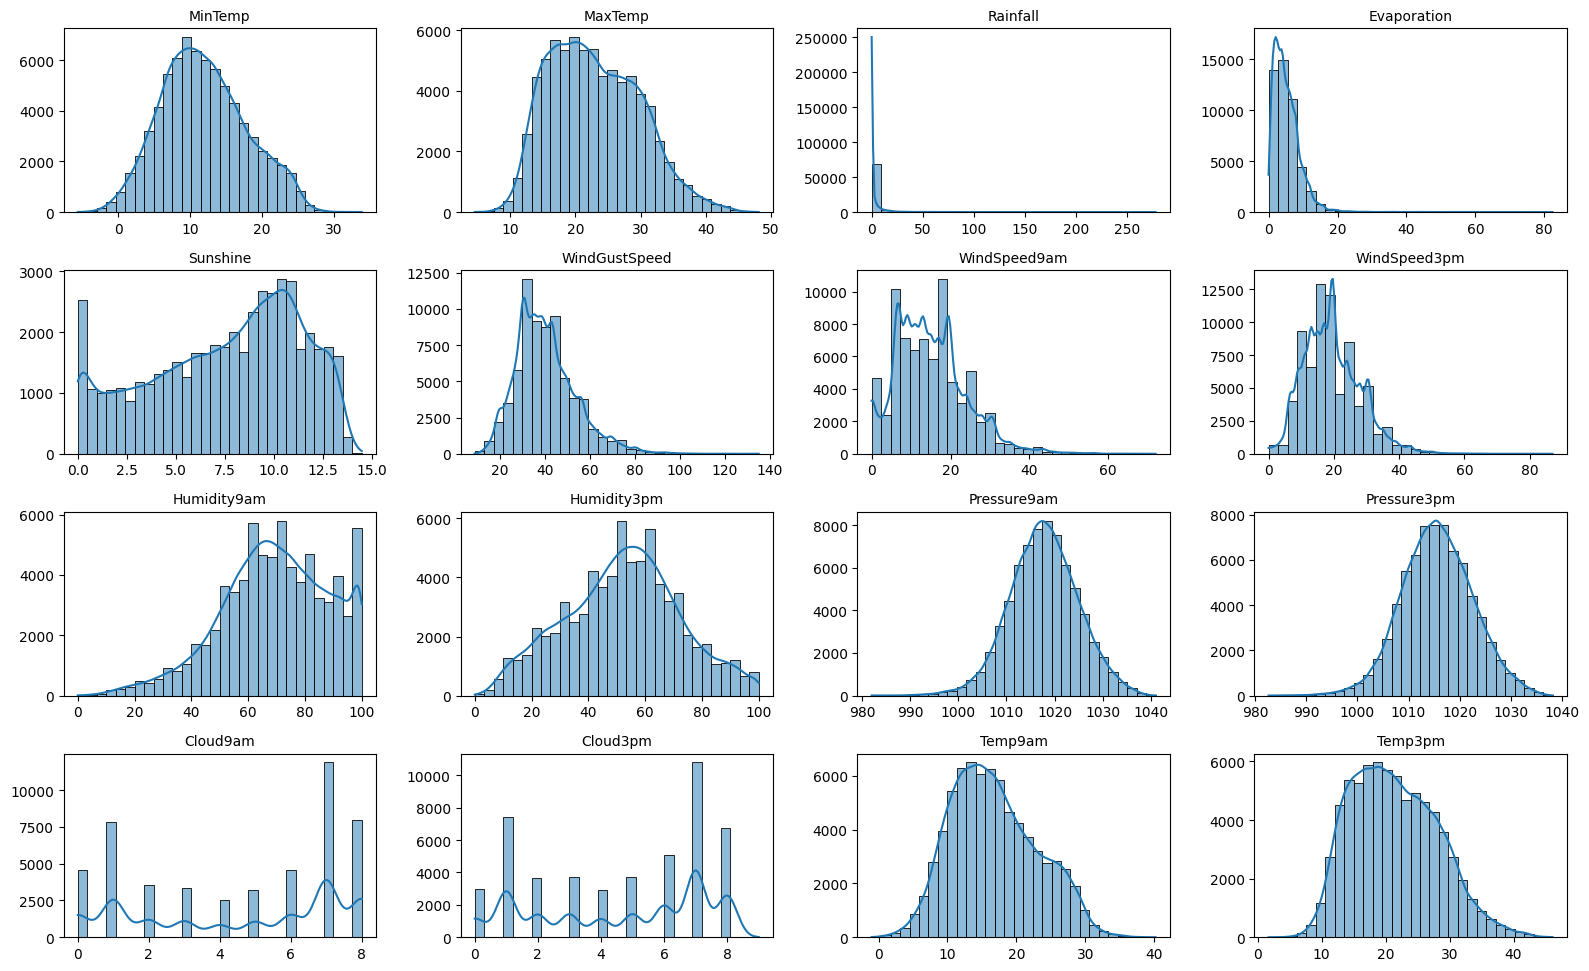

In [324]:
# Vemos las distribuciones de las variables numéricas
numericas = clima_australia.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(16, 12))

for i, col in enumerate(numericas, 1):
    plt.subplot(5, 4, i)
    sns.histplot(clima_australia[col], bins=30, kde=True)
    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

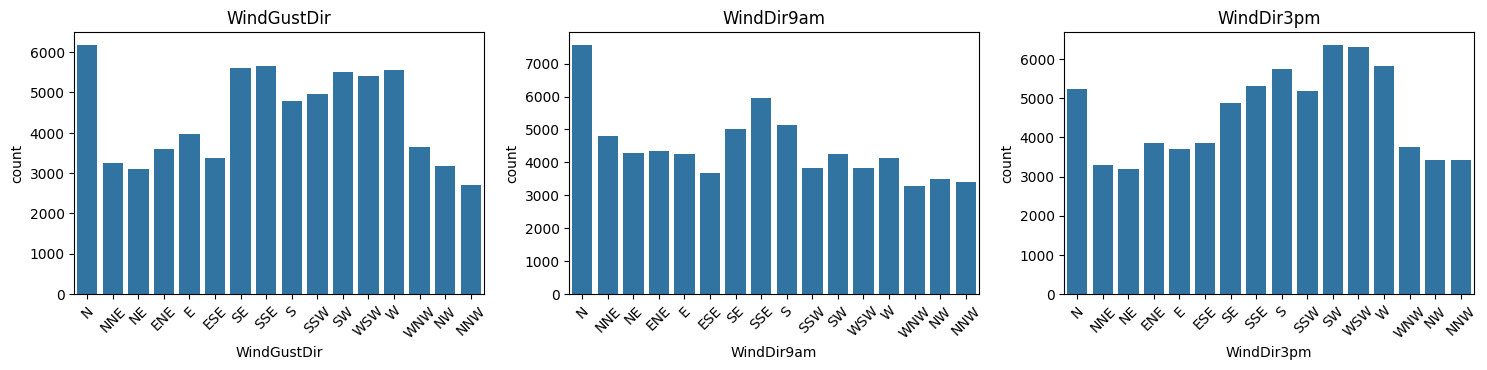

In [325]:
# Vemos la distribución de las variables WindGustDir, WindDir9am y WindDir3pm
categoricas = clima_australia.select_dtypes(include=["object"]).columns

categoricas = [col for col in categoricas if col not in ["Date", "Location","RainToday","RainTomorrow"]]
plt.figure(figsize=(15,10))
orden_viento = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]
for i, col in enumerate(categoricas, 1):
    plt.subplot(3, 3, i)
    sns.countplot(
        data=clima_australia,
        x=col,
        order=orden_viento
    )
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_67660/3188393684.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_67660/3188393684.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


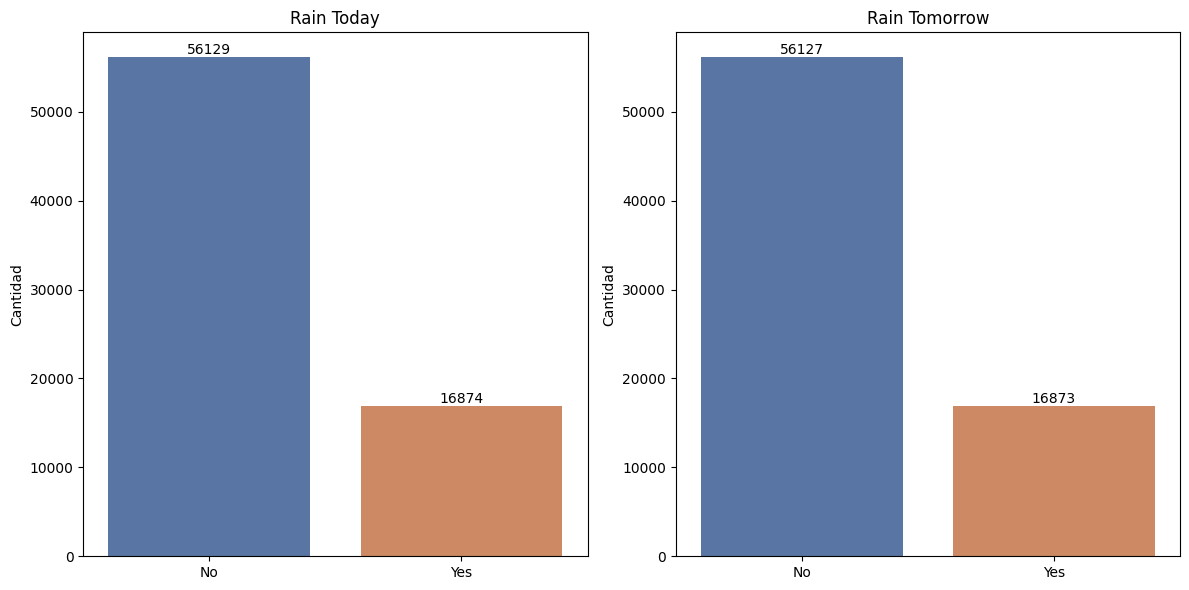

In [326]:
# Vemos la distribución entre los días que llueve y los días que no llueve, tanto para RainToday como RainTomorrow
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
orden = ["No", "Yes"]
colores = {"No": "#4C72B0", "Yes": "#DD8452"}

# Today
sns.countplot(
    data=clima_australia,
    x="RainToday",
    order=orden,
    palette=colores,
    ax=axes[0]
)
axes[0].set_title("Rain Today")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad")

# Tomorrow
sns.countplot(
    data=clima_australia,
    x="RainTomorrow",
    order=orden,
    palette=colores,
    ax=axes[1]
)
axes[1].set_title("Rain Tomorrow")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cantidad")

# Etiquetas
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

In [327]:
clima_australia.groupby(['RainToday', 'RainTomorrow']).size().unstack()

RainTomorrow,No,Yes
RainToday,,
No,47034,8669
Yes,8783,7891


A partir de esto, se observa que, si no llovió hoy, es más probable que tampoco llueva mañana; mientras que, si llovió hoy, aumenta la probabilidad de que llueva al día siguiente en comparación con los casos en los que no llovió.

In [328]:
# Acá vemos los valores que toma Cloud3pm y su cantidad
clima_australia["Cloud3pm"].value_counts().sort_index(ascending=False)

,count
Cloud3pm,
9.0,1
8.0,6715
7.0,10797
6.0,5084
5.0,3713
4.0,2923
3.0,3709
2.0,3635
1.0,7447


In [329]:
# Acá vemos los valores que toma Cloud9am y su cantidad
clima_australia["Cloud9am"].value_counts().sort_index(ascending=False)

,count
Cloud9am,
8.0,7945
7.0,11891
6.0,4582
5.0,3205
4.0,2506
3.0,3337
2.0,3562
1.0,7805
0.0,4587


Anteriormente habíamos visto que Cloud9am tomaba valores entre 0 y 8, pero no sabíamos si tomaba valores con decimales, lo cual estaría mal, ya que esta variable toma valores enteros del 0 al 8. Sin embargo, como vemos, tanto Cloud9am como Cloud3pm toman valores enteros del 0 al 8 correctamente, excepto Cloud3pm, que posee un único valor igual a 9, lo cual es un valor erróneo y a considerar en la etapa de limpieza de datos.

## 2.2 - Outliers

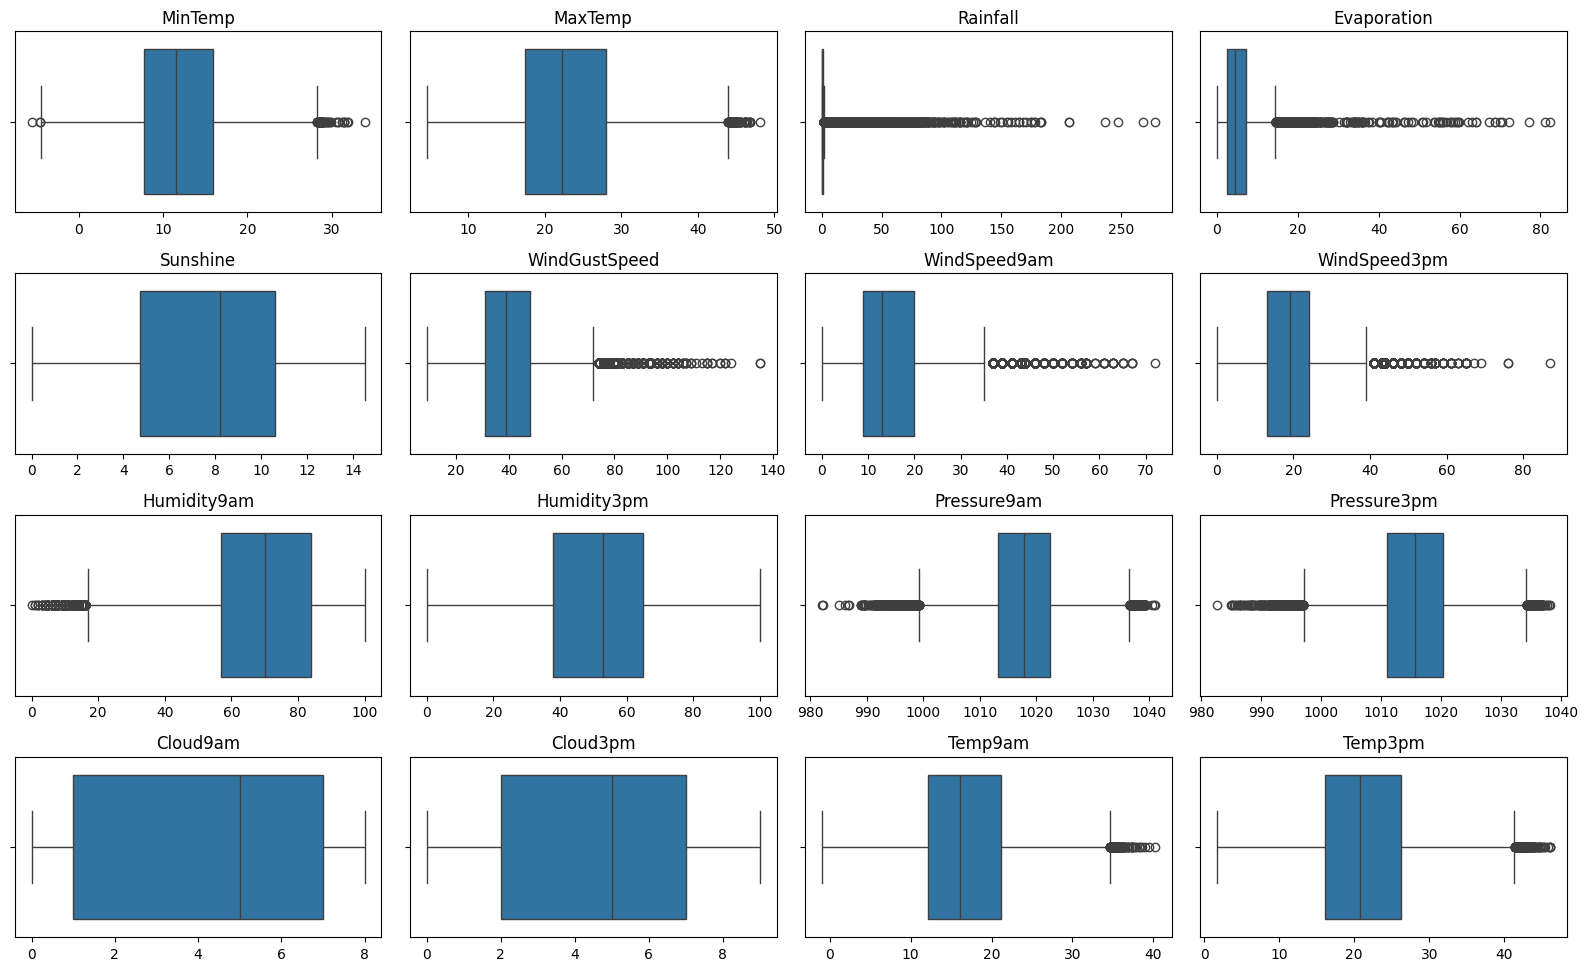

In [330]:
numericas = clima_australia.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(16, 12))

for i, col in enumerate(numericas, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x=clima_australia[col])
    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()

### Análisis de valores atípicos

A partir de los boxplots se identificaron valores atípicos en diversas variables.

En primer lugar, se observa que la mayoría de las variables se encuentra dentro de rangos esperables, aunque se detectó una inconsistencia puntual en Cloud3pm

La variable **Rainfall** presenta una gran cantidad de valores extremos hacia la derecha, lo cual refleja una distribución altamente sesgada. Esto es esperable, ya que los eventos de lluvia intensa son poco frecuentes pero pueden alcanzar valores elevados en situaciones de tormentas severas.Además, como vimos anteriormente, hay una mayor proporcion de dias de lluvia.

Las variables asociadas a la **velocidad del viento** también muestran la presencia de valores extremos, los cuales pueden interpretarse como momentos tormentas o ciclones poco frecuentes.

En el caso de las **temperaturas**, los valores extremos observados pueden asociarse a fenómenos como olas de calor o frío, manteniéndose dentro de rangos coherentes para el contexto geográfico analizado.

Las variables de **humedad** y **presión atmosférica** presentan menor proporción relativa de outliers, con valores que se mantienen dentro de rangos esperables. En particular, valores bajos de presión pueden estar asociados a sistemas de tormenta, mientras que valores altos indican condiciones más estables.

Por último, la variable **Evaporation**, además de presentar valores extremos, posee una alta proporción de datos faltantes. Los valores elevados observados pueden asociarse a períodos de altas temperaturas donde la evaporación es naturalmente mayor, como ocurre durante olas de calor o estaciones cálidas.

En general, los valores atípicos detectados no se consideran errores, sino representaciones válidas de fenómenos climáticos extremos.

## 2.3 - Correlación entre variables

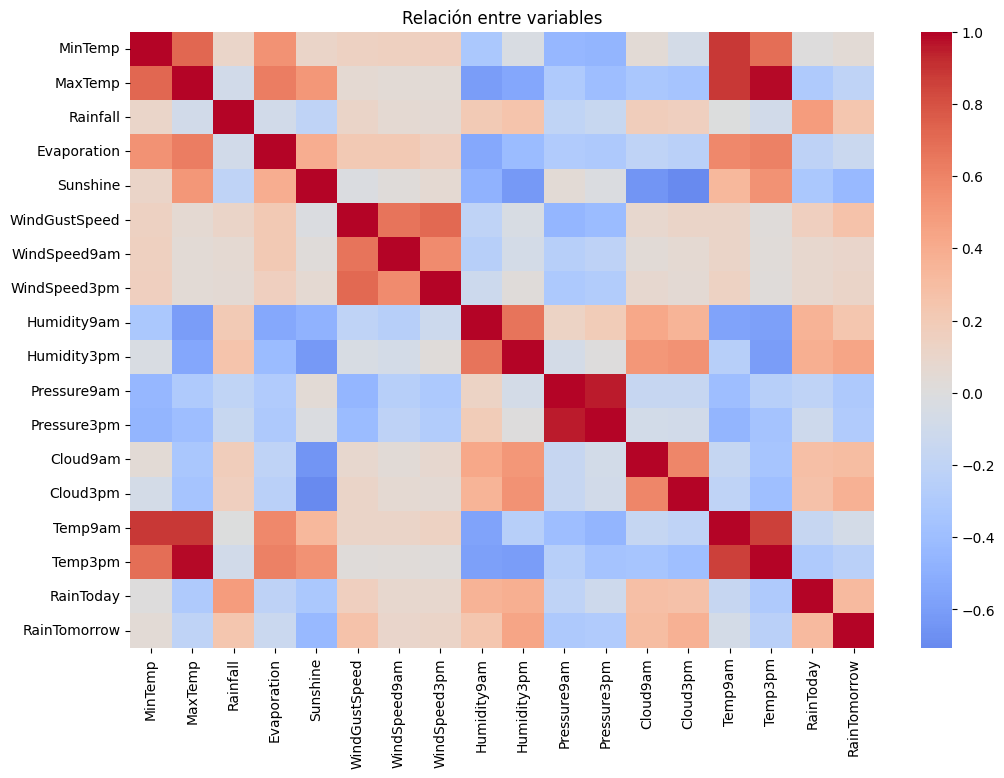

In [331]:
clima_australia_correlacion = clima_australia.copy()
clima_australia_correlacion["RainTomorrow"] = clima_australia_correlacion["RainTomorrow"].map({"Yes":1, "No":0})
clima_australia_correlacion["RainToday"] = clima_australia_correlacion["RainToday"].map({"Yes":1, "No":0})
clima_australia_numerico = clima_australia_correlacion.select_dtypes(include=['int64', 'float64'])
corr = clima_australia_numerico.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Relación entre variables")
plt.show()

En el heatmap de correlaciones se puede observar lo siguiente:

- RainTomorrow tiene una correlación positiva con Cloud3pm y Cloud9am lo que tiene sentido ya que mayormente cuando llueve el cielo esta nublado, además vemos que tiene un poco más de peso la variable Cloud3pm.
- RainTomorrow tiene una correlacion positiva con RainToday, lo cual indica que si llovio hoy, puede llover mañana
- RainTomorrow tiene una correlación positiva con Humidity9am y un poco más con Humidity3pm.
- Alta correlacion entre MinTemp y Temp9am
- Alta correlacion entre MaxTemp y Temp3pm
- Correlacion negativa entre Sushine y Cloud9am y Cloud3pm, lo que quiere decir que a mayor parte del cielo cubierto por nubes menor cantidad de horas de sol

## 2.4 - Relación con RainTomorrow

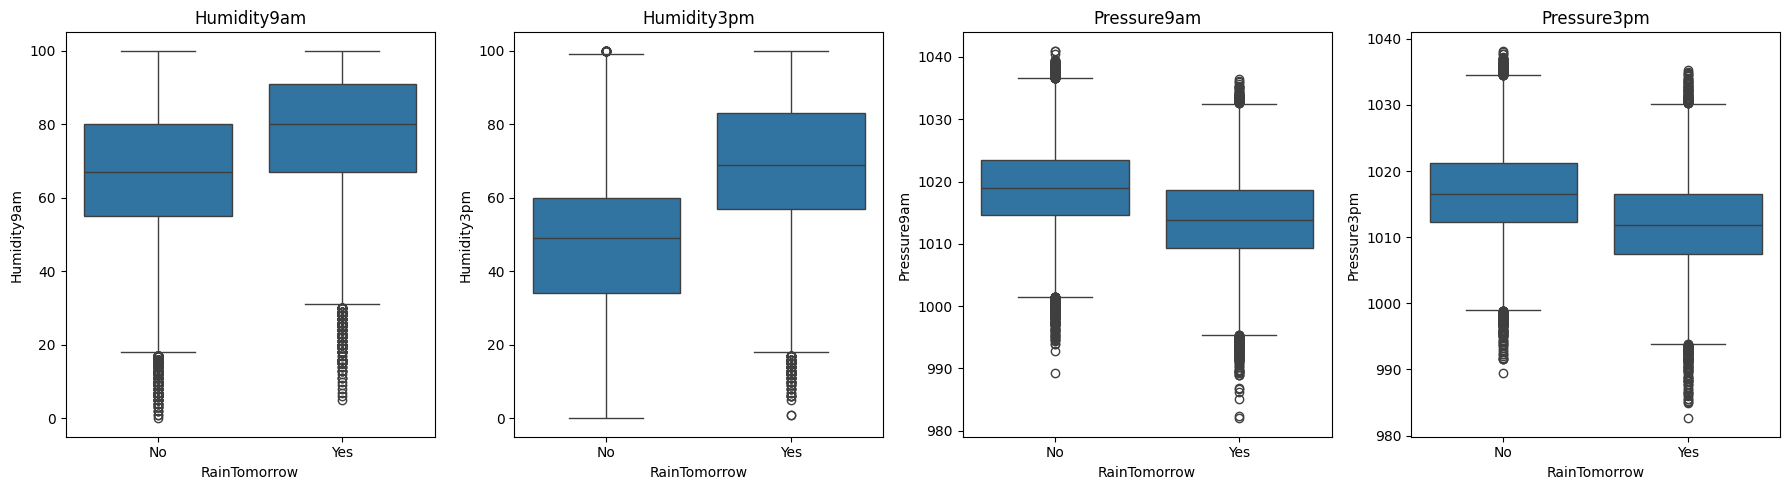

In [332]:
variables = ["Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm" ]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 5))

for i, var in enumerate(variables):
    sns.boxplot(
        x="RainTomorrow",
        y=var,
        data=clima_australia,
        ax=axes[i]
    )
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

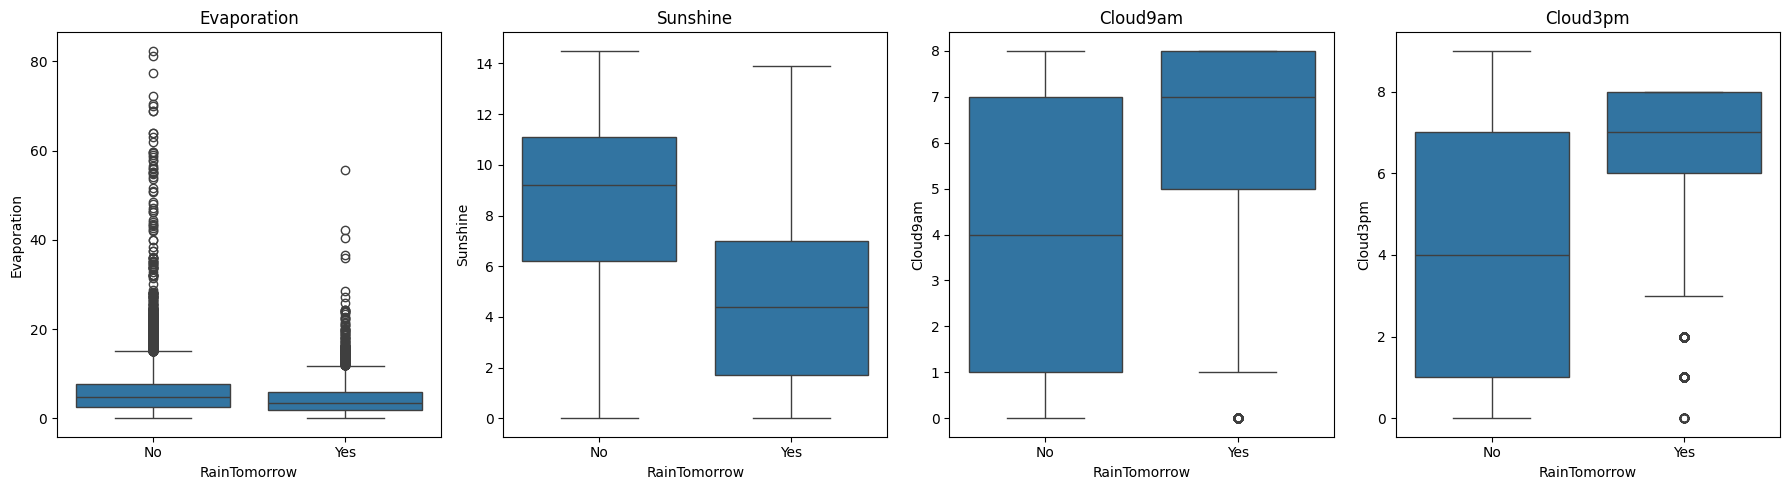

In [333]:
variables = ["Evaporation", "Sunshine", "Cloud9am", "Cloud3pm" ]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 5))

for i, var in enumerate(variables):
    sns.boxplot(
        x="RainTomorrow",
        y=var,
        data=clima_australia,
        ax=axes[i]
    )
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

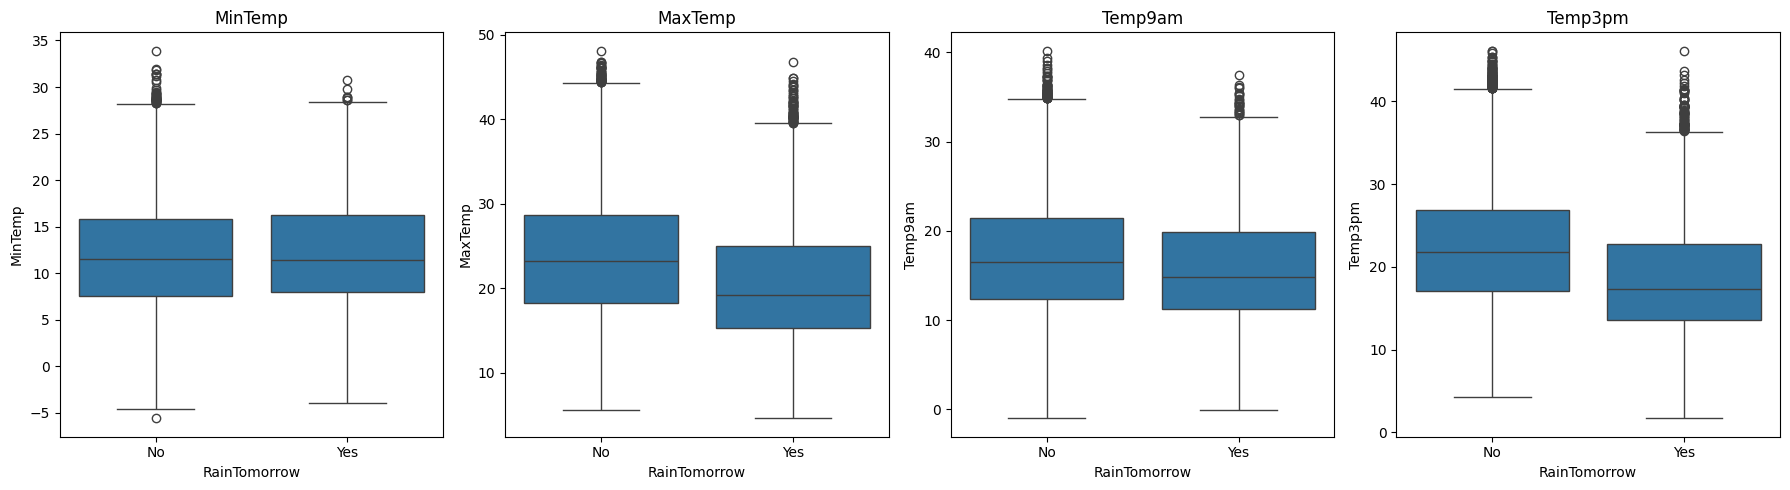

In [334]:
variables = ["MinTemp", "MaxTemp", "Temp9am", "Temp3pm" ]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 5))

for i, var in enumerate(variables):
    sns.boxplot(
        x="RainTomorrow",
        y=var,
        data=clima_australia,
        ax=axes[i]
    )
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

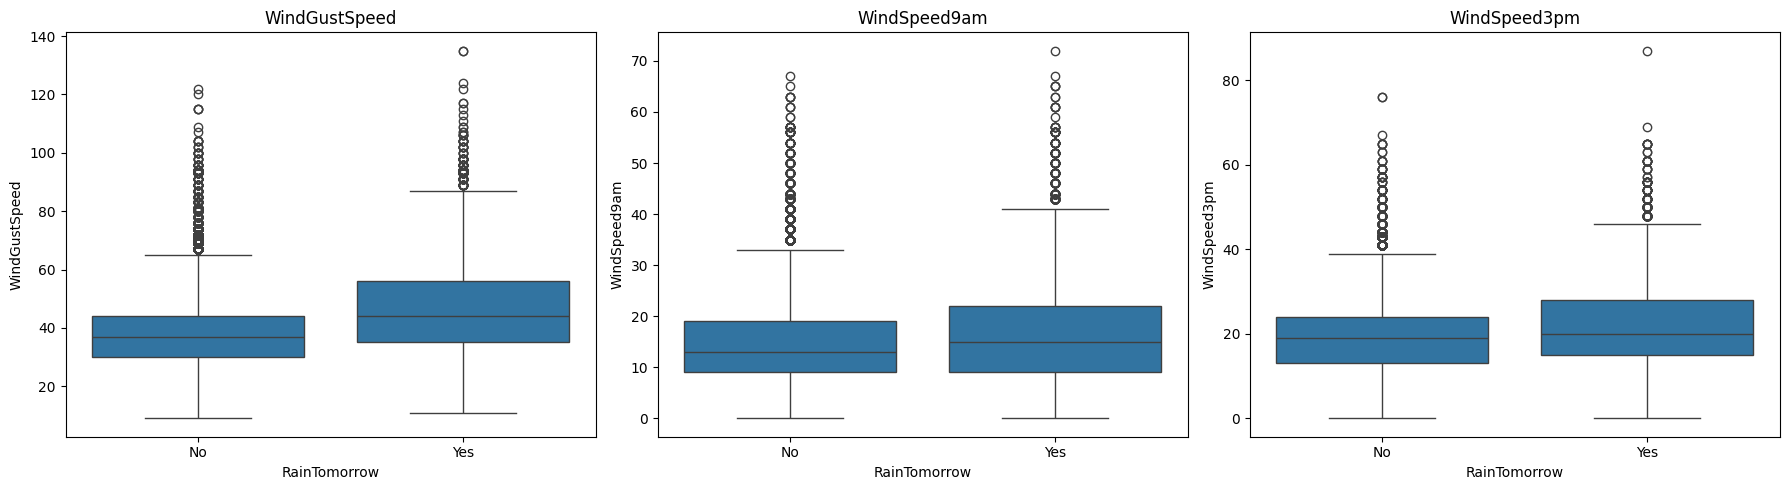

In [335]:
variables = ["WindGustSpeed", "WindSpeed9am", "WindSpeed3pm" ]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 5))

for i, var in enumerate(variables):
    sns.boxplot(
        x="RainTomorrow",
        y=var,
        data=clima_australia,
        ax=axes[i]
    )
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

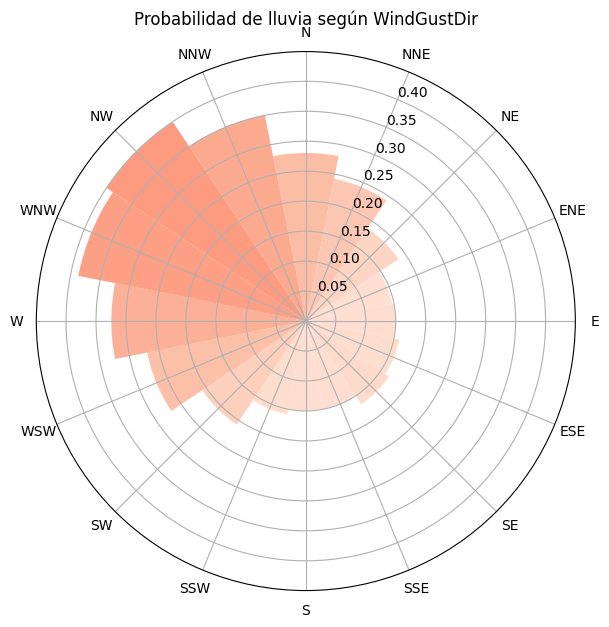

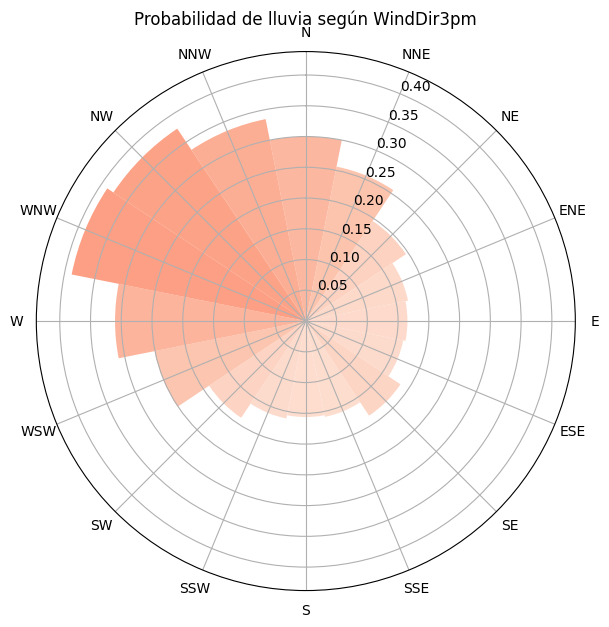

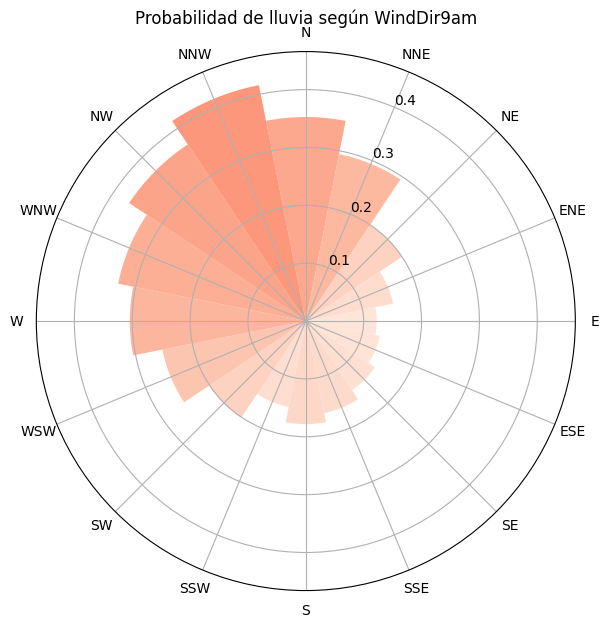

In [336]:
orden_direcciones = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

columnas = ["WindGustDir", "WindDir3pm", "WindDir9am"]

for col in columnas:
    tabla = pd.crosstab(
        clima_australia[col],
        clima_australia["RainTomorrow"],
        normalize="index"
    )

    probabilidades = tabla.reindex(orden_direcciones)["Yes"].fillna(0)

    angulos = np.linspace(0, 2 * np.pi, len(orden_direcciones), endpoint=False)
    ancho = 2 * np.pi / len(orden_direcciones)

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})

    barras = ax.bar(
        angulos,
        probabilidades,
        width=ancho,
        bottom=0
    )

    # Color más intenso cuanto mayor es la probabilidad
    for barra, prob in zip(barras, probabilidades):
        barra.set_facecolor(plt.cm.Reds(prob))
        barra.set_alpha(0.85)

    ax.set_theta_zero_location("N")   # 0 grados arriba
    ax.set_theta_direction(-1)        # sentido horario

    ax.set_xticks(angulos)
    ax.set_xticklabels(orden_direcciones)

    ax.set_ylim(0, probabilidades.max() + 0.05)

    ax.set_title(f"Probabilidad de lluvia según {col}", pad=20)

    plt.show()

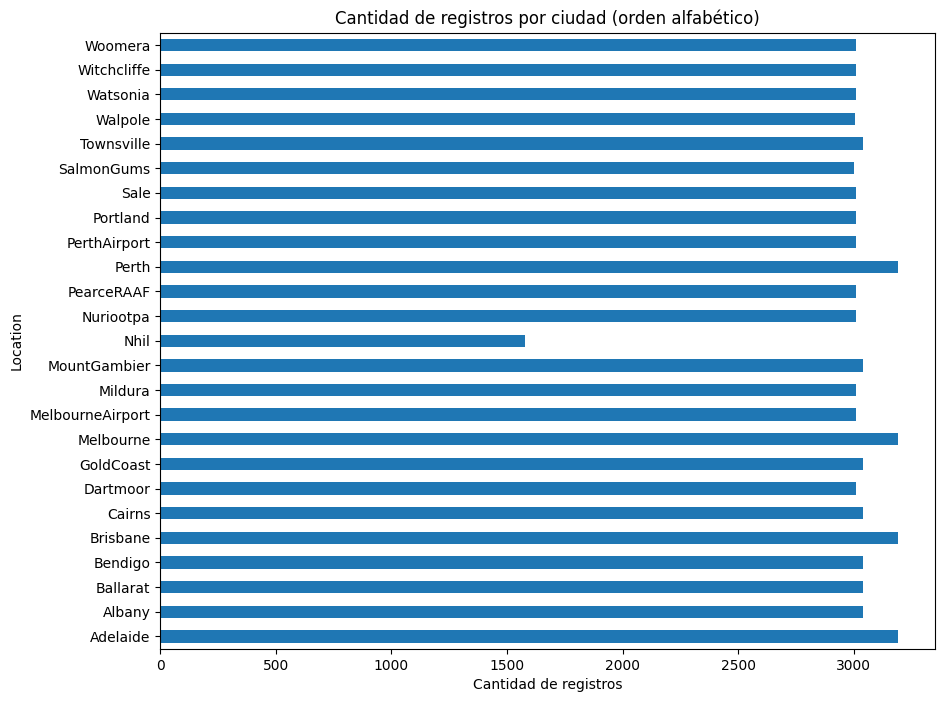

In [337]:
clima_australia_target_numerico = clima_australia.copy()

clima_australia_target_numerico["RainTomorrow"] = clima_australia_target_numerico["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

conteo_ciudades = (
    clima_australia_target_numerico
    .groupby("Location")
    .size()
    .sort_index()
)

plt.figure(figsize=(10,8))
conteo_ciudades.plot(kind="barh")

plt.xlabel("Cantidad de registros")
plt.title("Cantidad de registros por ciudad (orden alfabético)")

plt.show()

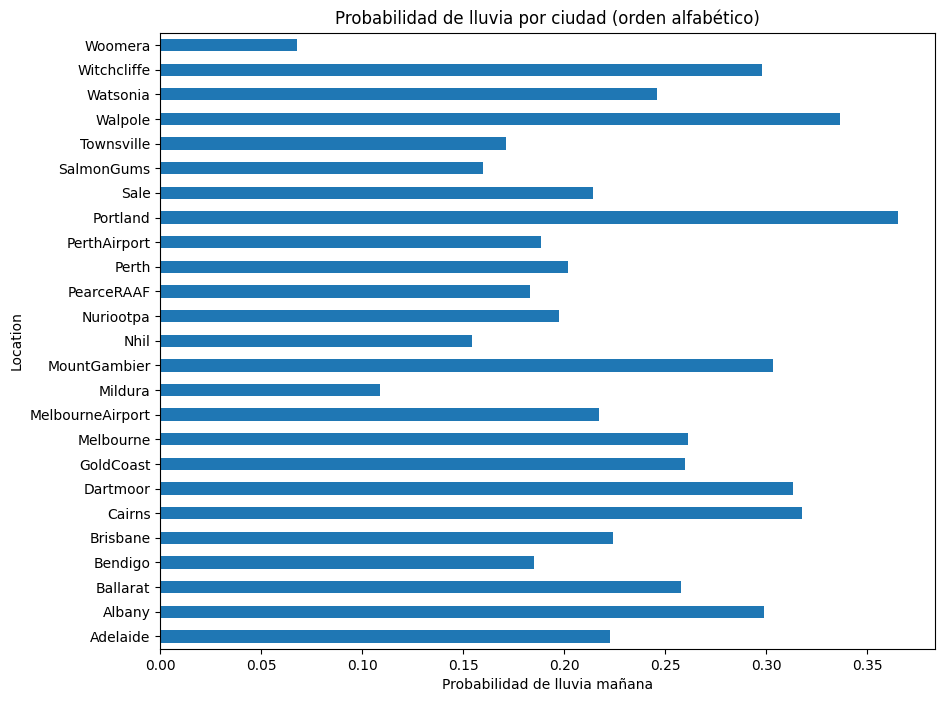

In [338]:
prob_lluvia = (
    clima_australia_target_numerico
    .groupby("Location")["RainTomorrow"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,8))
prob_lluvia.plot(kind="barh")

plt.xlabel("Probabilidad de lluvia mañana")
plt.title("Probabilidad de lluvia por ciudad (orden alfabético)")

plt.show()

# 3 - Limpieza de datos

##Valores faltantes

In [339]:
def tabla_nulos(dataframe):
    filas_totales = len(dataframe)

    tabla = pd.DataFrame({
        "Cantidad_NaN": dataframe.isnull().sum(),
        "Porcentaje_NaN": (dataframe.isnull().sum() / filas_totales) * 100
    })

    return tabla

In [340]:
#Vemos valores nulos
tabla_nulos(clima_australia)

,Cantidad_NaN,Porcentaje_NaN
Date,0,0.000000
Location,0,0.000000
MinTemp,778,1.040998
MaxTemp,761,1.018251
Rainfall,1733,2.318829
Evaporation,26889,35.978645
Sunshine,26440,35.377863
WindGustDir,4241,5.674641
WindGustSpeed,4190,5.606401
WindDir9am,3457,4.625615


In [341]:
# Se eliminan las filas que contienen valores nulos en la variable RainTomorrow,
# dado que es la variable objetivo y su ausencia impide validar correctamente las predicciones.

clima_australia = clima_australia.dropna(subset=['RainTomorrow'])
tabla_nulos(clima_australia)

,Cantidad_NaN,Porcentaje_NaN
Date,0,0.000000
Location,0,0.000000
MinTemp,161,0.220548
MaxTemp,87,0.119178
Rainfall,623,0.853425
Evaporation,26138,35.805479
Sunshine,25918,35.504110
WindGustDir,3880,5.315068
WindGustSpeed,3831,5.247945
WindDir9am,3256,4.460274


In [342]:
# Se observa la presencia de 623 valores nulos tanto en RainToday como en Rainfall.
# Dado que existe una relación entre ambas variables, se analizará si la ausencia de datos ocurre de manera conjunta.
(clima_australia["RainToday"].isnull() ==
 clima_australia["Rainfall"].isnull()).all()

np.True_

In [343]:
# Se observa que los valores nulos coinciden en ambas variables, y considerando que RainToday depende de Rainfall,
# y que estos representan aproximadamente un 0,9% del conjunto de datos, se opta por eliminar dichos registros,
# ya que no permiten determinar correctamente la variable y podrían introducir ruido o inconsistencias en el modelo.

clima_australia = clima_australia.dropna(subset=["Rainfall"])

tabla_nulos(clima_australia)


,Cantidad_NaN,Porcentaje_NaN
Date,0,0.000000
Location,0,0.000000
MinTemp,111,0.153364
MaxTemp,82,0.113296
Rainfall,0,0.000000
Evaporation,25719,35.534769
Sunshine,25659,35.451870
WindGustDir,3784,5.228180
WindGustSpeed,3737,5.163242
WindDir9am,3198,4.418531


In [344]:
# Se elimina la fila que contiene un valor no válido en la variable Cloud3pm, previamente identificado en el análisis.
clima_australia = clima_australia[clima_australia["Cloud3pm"] != 9]

In [345]:
# Revisamos si hay duplicados.
clima_australia.duplicated().sum()

np.int64(0)

/tmp/ipykernel_67660/3414073960.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  faltantes_por_localizacion = clima_australia.groupby("Location").apply(


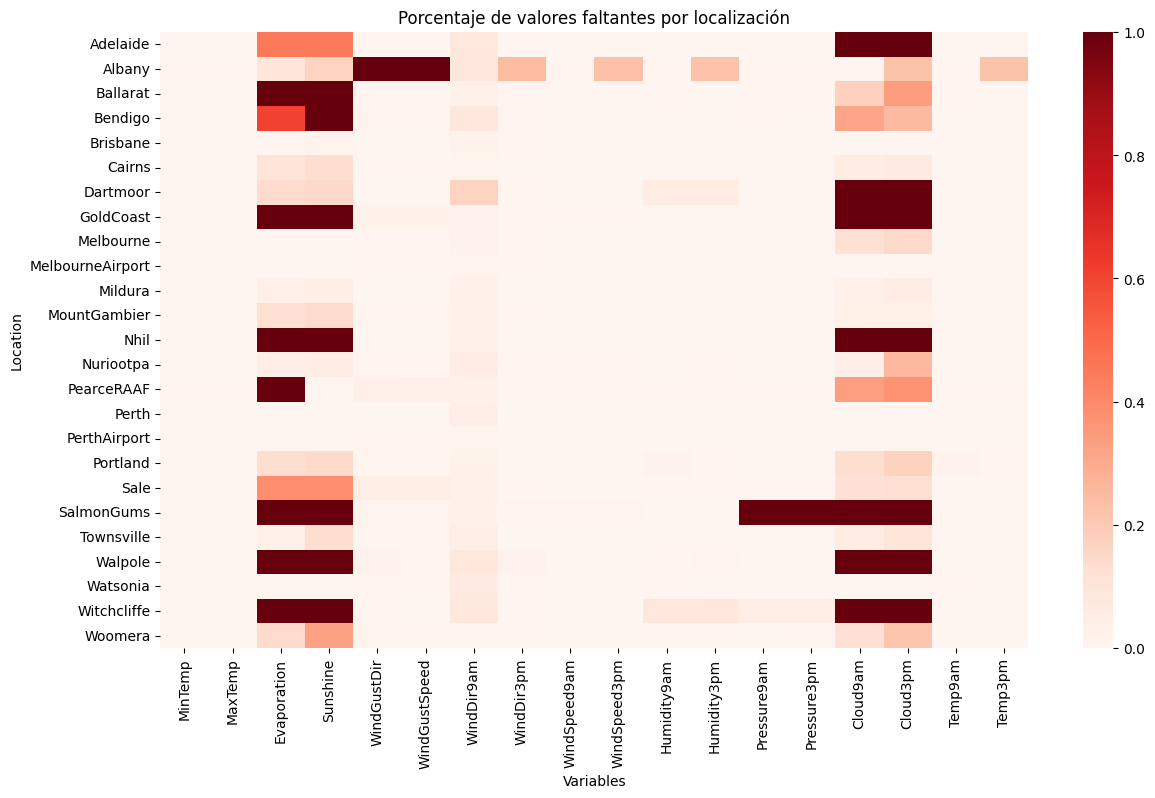

In [346]:
# Ahora analizaremos si existe una relación entre los valores faltantes y las ciudades.
faltantes_por_localizacion = clima_australia.groupby("Location").apply(
    lambda x: x.isnull().mean()
)
cols_excluir = ["Date","Location","Rainfall","RainToday","RainTomorrow"]

cols_mostrar = [col for col in faltantes_por_localizacion.columns if col not in cols_excluir]
plt.figure(figsize=(14,8))

sns.heatmap(
    faltantes_por_localizacion[cols_mostrar],
    cmap="Reds",
    annot=False
)

plt.title("Porcentaje de valores faltantes por localización")
plt.ylabel("Location")
plt.xlabel("Variables")
plt.show()

Se ve que hay estaciones meteorologicas que no miden ciertos datos en algunas ciudades, ya que hay ciudades donde ciertas variables tienen un 100% de valores faltantes.

In [347]:
# Se evalúa la eliminación de la variable Evaporation, dado que, según el análisis previo del heatmap de correlaciones,
# muestra una baja relación con la variable objetivo. Asimismo, no aporta información significativa para la predicción de lluvia, como vimos anteriormente.
clima_australia.drop(columns=["Evaporation"], inplace=True)


In [348]:
def imputar_por_localizacion(df, columna_localizacion="Location"):
    df = df.copy()

    # Columnas numéricas y categóricas
    columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    columnas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

    # No queremos imputar la columna Location con sí misma
    if columna_localizacion in columnas_categoricas:
        columnas_categoricas.remove(columna_localizacion)

    # ---------- NUMÉRICAS: mediana por Location, si no mediana global ----------
    for col in columnas_numericas:
        mediana_global = df[col].median()

        medianas_por_loc = df.groupby(columna_localizacion)[col].transform("median")

        df[col] = df[col].fillna(medianas_por_loc)

        if not pd.isna(mediana_global):
            df[col] = df[col].fillna(mediana_global)

    # ---------- CATEGÓRICAS: moda por Location, si no moda global ----------
    for col in columnas_categoricas:
        # Moda global
        moda_global = df[col].mode(dropna=True)
        moda_global = moda_global.iloc[0] if not moda_global.empty else np.nan

        # Moda por localización
        moda_por_loc = df.groupby(columna_localizacion)[col].transform(
            lambda x: x.mode(dropna=True).iloc[0] if not x.mode(dropna=True).empty else np.nan
        )

        df[col] = df[col].fillna(moda_por_loc)

        if not pd.isna(moda_global):
            df[col] = df[col].fillna(moda_global)

    return df

In [349]:
#Imputamos los datos faltantes con la mediana y la moda a las variables correspondientes, incluso en las variables Cloud9am y Cloud3pm, ya que estas variables tienen una correlacion positiva con respecto a la lluvia, y en la realidad es lo que suele suceder
clima_australia_imputado = imputar_por_localizacion(clima_australia)
clima_australia_imputado.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0


Los valores faltantes en variables numéricas fueron imputados utilizando la mediana de la variable dentro de cada localización, con el objetivo de preservar las particularidades climáticas de cada ciudad. En aquellos casos donde una localización no contaba con datos suficientes para calcular la mediana, se utilizó la mediana global de la variable. Para las variables categóricas se siguió un criterio análogo, imputando con la moda por localización y, en caso de no ser posible, con la moda global.

In [350]:
clima_australia_imputado.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
55102,2008-12-01,Ballarat,5.8,17.6,3.2,8.3,W,52.0,W,WNW,...,71.0,37.0,1008.2,1007.5,6.0,8.0,10.4,15.7,Yes,No
55103,2008-12-02,Ballarat,4.3,19.5,0.4,8.3,WNW,44.0,WNW,WNW,...,66.0,47.0,1009.3,1007.3,6.0,8.0,12.5,17.6,No,No
55104,2008-12-03,Ballarat,9.5,18.8,0.6,8.3,W,43.0,WSW,SW,...,82.0,42.0,1009.5,1011.5,4.0,8.0,11.2,16.5,No,No
55105,2008-12-04,Ballarat,6.7,21.8,0.2,8.3,NNE,39.0,ENE,N,...,60.0,33.0,1016.2,1012.6,4.0,8.0,14.4,20.6,No,Yes
55106,2008-12-05,Ballarat,13.3,25.6,1.2,8.3,NW,61.0,NNW,NW,...,74.0,40.0,1006.6,1005.5,6.0,1.0,18.3,24.3,Yes,No
55107,2008-12-06,Ballarat,9.6,23.0,0.0,8.3,WNW,61.0,WNW,WNW,...,76.0,42.0,1009.6,1005.7,6.0,6.0,13.8,20.8,No,No
55108,2008-12-07,Ballarat,4.6,16.4,0.0,8.3,SW,39.0,SW,SW,...,71.0,42.0,1012.3,1012.1,4.0,4.0,9.6,15.6,No,No
55109,2008-12-08,Ballarat,2.9,23.1,0.2,8.3,NW,43.0,SSE,WSW,...,64.0,30.0,1014.0,1010.5,4.0,8.0,9.7,20.6,No,No
55110,2008-12-09,Ballarat,5.3,17.6,0.0,8.3,S,35.0,NW,SSE,...,55.0,87.0,1007.5,1006.4,8.0,8.0,13.2,12.4,No,Yes
55111,2008-12-10,Ballarat,8.3,18.3,5.0,8.3,SE,50.0,SSE,SE,...,71.0,43.0,1011.8,1010.9,6.0,8.0,10.6,18.1,Yes,No


In [351]:
clima_australia["Cloud9am"].value_counts().sort_index(ascending=False)

,count
Cloud9am,
8.0,7806
7.0,11747
6.0,4529
5.0,3159
4.0,2471
3.0,3294
2.0,3531
1.0,7742
0.0,4555


In [352]:
clima_australia["Cloud3pm"].value_counts().sort_index(ascending=False)

,count
Cloud3pm,
8.0,6599
7.0,10674
6.0,5014
5.0,3678
4.0,2882
3.0,3662
2.0,3604
1.0,7367
0.0,2982


# 4 - Transformación de datos

In [353]:
# Se transforma el tipo de dato de la variable Date de object a datetime con el fin de facilitar su procesamiento.
clima_australia_imputado["Date"] = pd.to_datetime(clima_australia_imputado["Date"])
# Se crea una nueva variable que representa la estación del año (verano, otoño, invierno, primavera),
# dado que puede aportar mayor información que la fecha para la predicción de lluvia.
clima_australia_imputado["Estacion"] = clima_australia_imputado["Date"].dt.month.map({
    12: "Verano", 1: "Verano", 2: "Verano",
    3: "Otoño", 4: "Otoño", 5: "Otoño",
    6: "Invierno", 7: "Invierno", 8: "Invierno",
    9: "Primavera", 10: "Primavera", 11: "Primavera"
})
# Eliminamos la variable Date, ya que contamos con la variable Estación,
# la cual probablemente aporte mayor información que la fecha para la predicción.
clima_australia_imputado = clima_australia_imputado.drop(columns=["Date"])

# Se realiza la transformación de los valores "Yes" y "No" a 1 y 0 en las variables RainToday y RainTomorrow,
# para garantizar la compatibilidad con los modelos a utilizar y facilitar el análisis estadístico.
clima_australia_imputado["RainTomorrow"] = clima_australia_imputado["RainTomorrow"].map({"No": 0, "Yes": 1})
clima_australia_imputado["RainToday"] = clima_australia_imputado["RainToday"].map({"No": 0, "Yes": 1})
clima_australia_imputado.head(5)

,Location,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Estacion
55102,Ballarat,5.8,17.6,3.2,8.3,W,52.0,W,WNW,26.0,...,37.0,1008.2,1007.5,6.0,8.0,10.4,15.7,1,0,Verano
55103,Ballarat,4.3,19.5,0.4,8.3,WNW,44.0,WNW,WNW,20.0,...,47.0,1009.3,1007.3,6.0,8.0,12.5,17.6,0,0,Verano
55104,Ballarat,9.5,18.8,0.6,8.3,W,43.0,WSW,SW,22.0,...,42.0,1009.5,1011.5,4.0,8.0,11.2,16.5,0,0,Verano
55105,Ballarat,6.7,21.8,0.2,8.3,NNE,39.0,ENE,N,9.0,...,33.0,1016.2,1012.6,4.0,8.0,14.4,20.6,0,1,Verano
55106,Ballarat,13.3,25.6,1.2,8.3,NW,61.0,NNW,NW,30.0,...,40.0,1006.6,1005.5,6.0,1.0,18.3,24.3,1,0,Verano


<Axes: xlabel='Estacion', ylabel='RainTomorrow'>

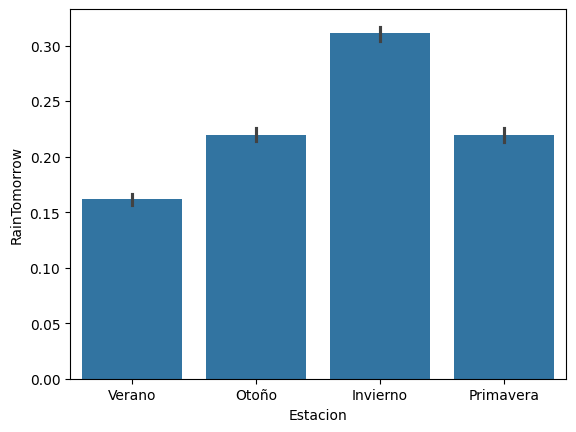

In [354]:
sns.barplot(x="Estacion", y="RainTomorrow", data=clima_australia_imputado)

In [355]:
clima_australia_con_dummies =  pd.get_dummies(
    clima_australia_imputado,
    columns=[
        "Location",
        "Estacion",
        "WindDir9am",
        "WindDir3pm",
        "WindGustDir"
    ],
    drop_first=True
)
clima_australia_con_dummies.head(5)

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,...,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW
55102,5.8,17.6,3.2,8.3,52.0,26.0,30.0,71.0,37.0,1008.2,...,False,False,False,False,False,False,False,True,False,False
55103,4.3,19.5,0.4,8.3,44.0,20.0,24.0,66.0,47.0,1009.3,...,False,False,False,False,False,False,False,False,True,False
55104,9.5,18.8,0.6,8.3,43.0,22.0,20.0,82.0,42.0,1009.5,...,False,False,False,False,False,False,False,True,False,False
55105,6.7,21.8,0.2,8.3,39.0,9.0,22.0,60.0,33.0,1016.2,...,False,False,False,False,False,False,False,False,False,False
55106,13.3,25.6,1.2,8.3,61.0,30.0,39.0,74.0,40.0,1006.6,...,False,True,False,False,False,False,False,False,False,False


# 5 - Entrenamiento de modelos

En algunos modelos se probaron pocas combinaciones de hiperparámetros porque se priorizaron valores considerados razonables para evitar sobreajuste. Al ampliar demasiado el rango de búsqueda, el modelo podía mejorar en entrenamiento pero empeorar en prueba, o bien no mostrar mejoras significativas en las métricas buscadas. Por este motivo, se trabajó con un espacio de búsqueda acotado y orientado a obtener modelos que generalicen mejor.

In [356]:
def entrenar_modelo(modelo, param_grid, X_train,y_train):

    # GridSearch
    grid = GridSearchCV(
        modelo,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Mejores hiperparámetros:", grid.best_params_)
    print("Mejor f1 en CV:", grid.best_score_)

    # Mejor modelo
    modelo_opt = grid.best_estimator_

    return modelo_opt

In [357]:
def evaluar_modelo(modelo_opt, X_train, X_test, y_train, y_test):

    # Predicciones TEST
    y_pred = modelo_opt.predict(X_test)
    y_prob = modelo_opt.predict_proba(X_test)[:, 1]

    # Overfitting check
    y_train_pred = modelo_opt.predict(X_train)
    y_train_prob = modelo_opt.predict_proba(X_train)[:, 1]

    # TEST
    y_test_pred = y_pred
    y_test_prob = y_prob

    cm = confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 🔹 1. Matriz de confusión
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"],
        ax=axes[0]
    )

    axes[0].set_xlabel("Predicción")
    axes[0].set_ylabel("Real")
    axes[0].set_title("Matriz de confusión")


    # 🔹 2. Curva ROC
    RocCurveDisplay.from_predictions(
        y_test,
        y_test_prob,
        ax=axes[1]
    )

    axes[1].set_title("Curva ROC")


    # 🔹 3. Métricas (texto)
    axes[2].axis("off")  # sin ejes

    texto = f"""
    TRAIN:
    ROC AUC: {roc_auc_score(y_train, y_train_prob):.4f}
    Accuracy: {accuracy_score(y_train, y_train_pred):.4f}
    Precision: {precision_score(y_train, y_train_pred):.4f}
    Recall: {recall_score(y_train, y_train_pred):.4f}
    F1: {f1_score(y_train, y_train_pred):.4f}

    TEST:
    ROC AUC: {roc_auc_score(y_test, y_test_prob):.4f}
    Accuracy: {accuracy_score(y_test, y_test_pred):.4f}
    Precision: {precision_score(y_test, y_test_pred):.4f}
    Recall: {recall_score(y_test, y_test_pred):.4f}
    F1: {f1_score(y_test, y_test_pred):.4f}
    """

    axes[2].text(0, 0.5, texto, fontsize=11, va="center")

    axes[2].set_title("Métricas")

    plt.tight_layout()
    plt.show()


In [358]:
X = clima_australia_con_dummies.drop("RainTomorrow", axis=1)
y = clima_australia_con_dummies["RainTomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [359]:
#Balanceo de clases
#El balanceo se aplicó únicamente sobre el conjunto de entrenamiento para evitar
#fuga de información hacia el conjunto de prueba.

# combinar train
train_df = pd.concat([X_train, y_train], axis=1)

# separar clases
mayoria = train_df[train_df["RainTomorrow"] == 0]
minoria = train_df[train_df["RainTomorrow"] == 1]

# oversampling (duplicar minoría)
minoria_upsampled = resample(
    minoria,
    replace=True,
    n_samples=len(mayoria),
    random_state=42
)

# juntar
train_balanceado = pd.concat([mayoria, minoria_upsampled])

X_train_bal = train_balanceado.drop("RainTomorrow", axis=1)
y_train_bal = train_balanceado["RainTomorrow"]

print(y_train.value_counts())
print(y_train_bal.value_counts())

RainTomorrow
0    44652
1    13248
Name: count, dtype: int64
RainTomorrow
0    44652
1    44652
Name: count, dtype: int64


## 5.1.0 - Decision Tree

Árbol de decisión cargado desde disco
Mejores hiperparametros:
max_depth: 10
min_samples_split: 2
min_samples_leaf: 25
criterion: gini


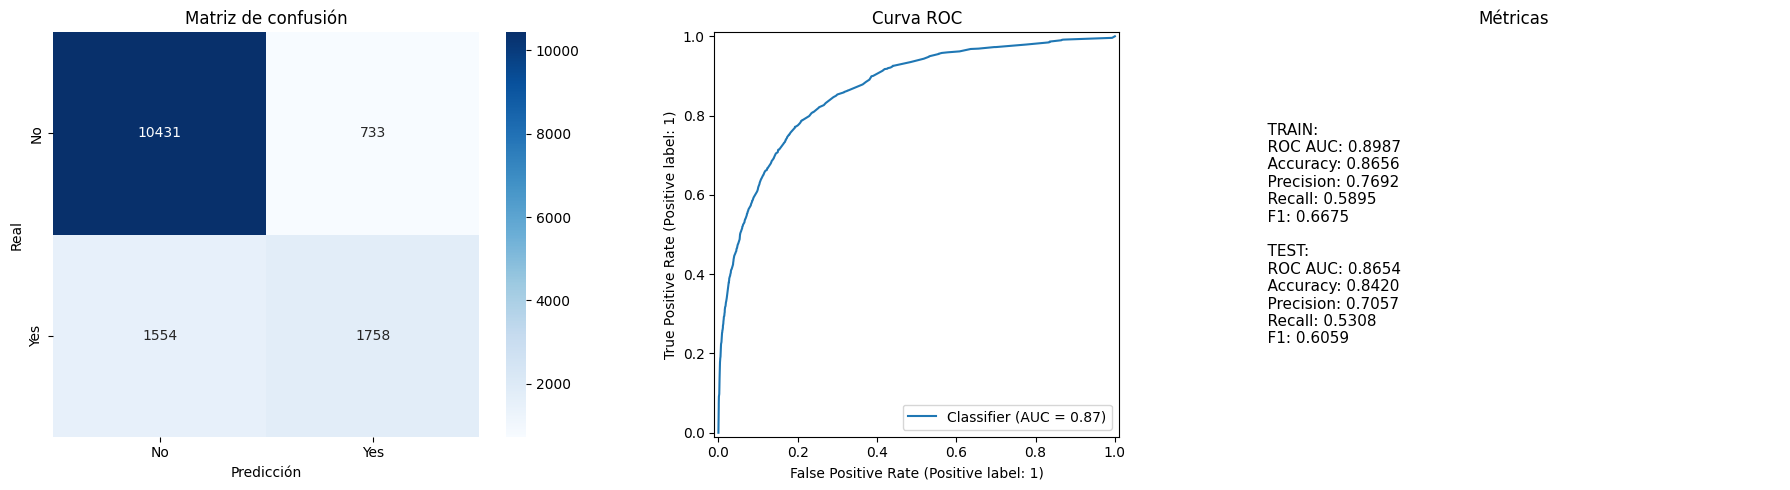

In [360]:
RUTA_DT = "modelos/arbol_de_decision.joblib"

if os.path.exists(RUTA_DT):
    modelo_dt_opt = joblib.load(RUTA_DT)
    print("Árbol de decisión cargado desde disco")
    params = modelo_dt_opt.get_params()
    print("Mejores hiperparametros:")

    print(f"max_depth: {params['max_depth']}")
    print(f"min_samples_split: {params['min_samples_split']}")
    print(f"min_samples_leaf: {params['min_samples_leaf']}")
    print(f"criterion: {params['criterion']}")

else:
    modelo_dt = DecisionTreeClassifier(random_state=42)

    param_grid_dt = {
        "criterion": ["gini"],
        "max_depth": [5, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 5, 10, 25],
    }

    modelo_dt_opt = entrenar_modelo(
        modelo_dt,
        param_grid_dt,
        X_train,
        y_train
    )

    joblib.dump(modelo_dt_opt, RUTA_DT)
    print("Árbol de decisión entrenado y guardado")

evaluar_modelo(modelo_dt_opt, X_train, X_test, y_train, y_test)

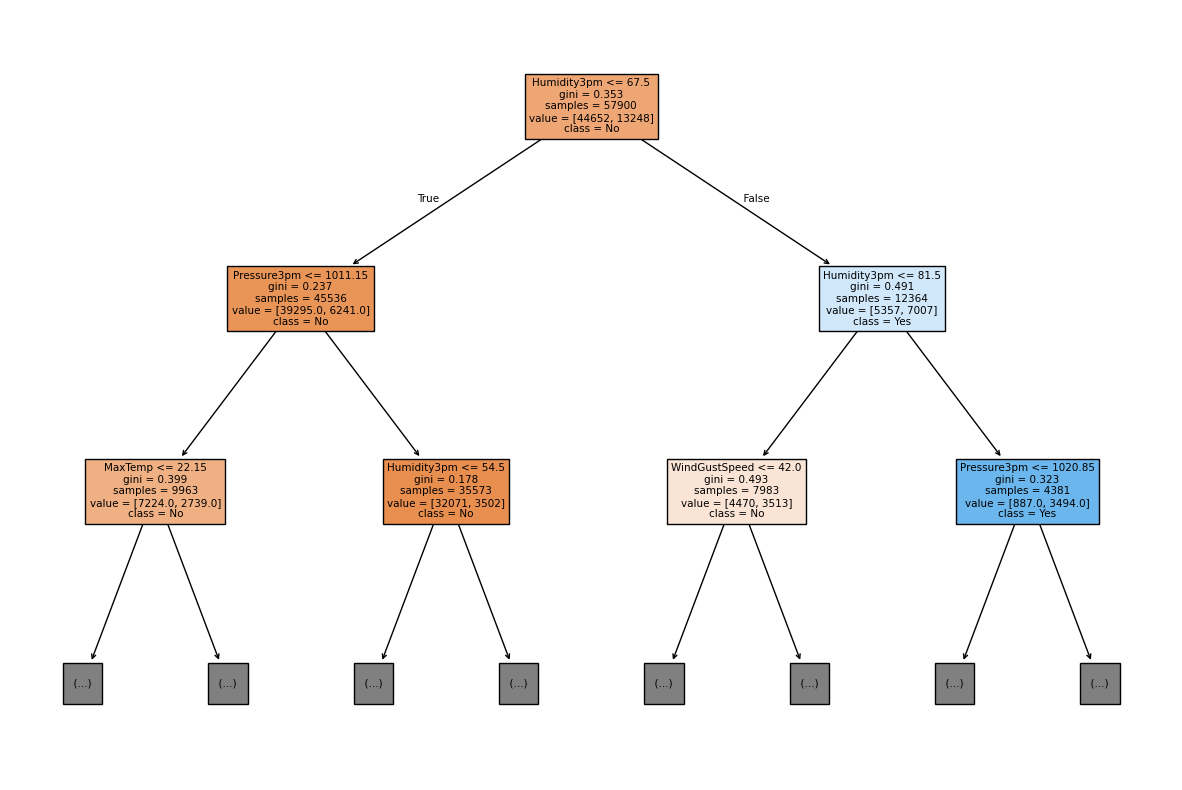

In [361]:
plt.figure(figsize=(15,10))
plot_tree(
    modelo_dt_opt,
    max_depth=2,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.show()

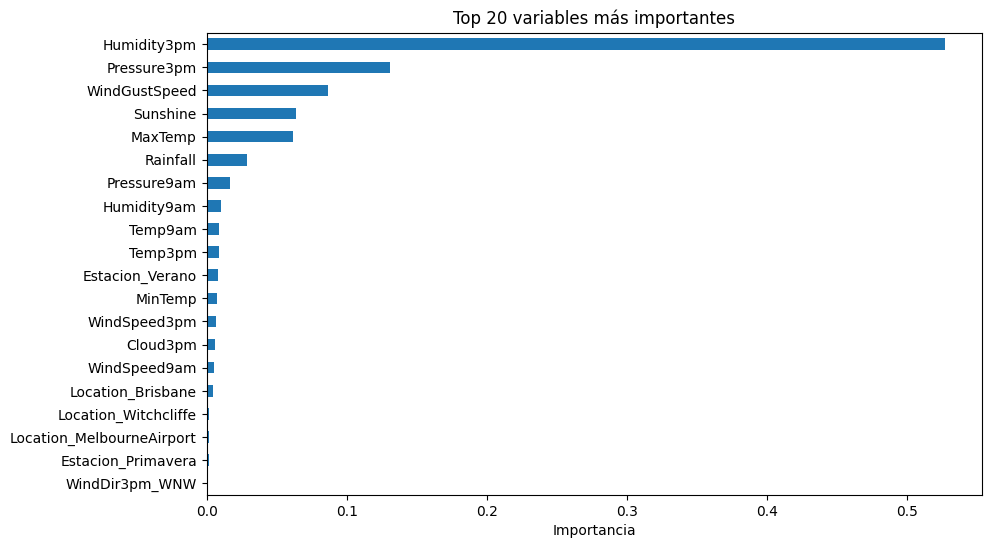

In [362]:
importancias = pd.Series(
    modelo_dt_opt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(20).plot(kind="barh")

plt.xlabel("Importancia")
plt.title("Top 20 variables más importantes")
plt.gca().invert_yaxis()

plt.show()

## 5.1.1 - Decision Tree con balanceo de clases



Árbol de decisión con balanceo cargado desde disco
Mejores hiperparametros:
max_depth: 20
min_samples_split: 100
min_samples_leaf: 75
criterion: gini


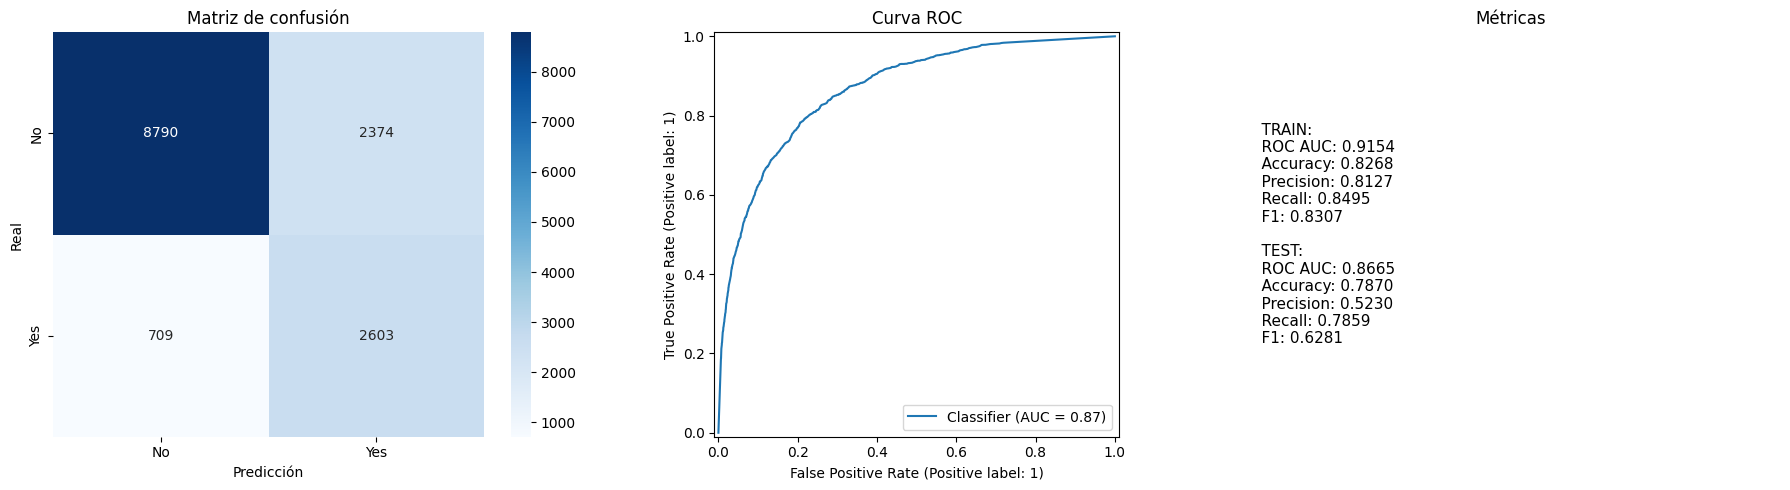

In [363]:
RUTA_DT_BAL = "modelos/arbol_de_decision_con_balanceo.joblib"

if os.path.exists(RUTA_DT_BAL):
    modelo_dt_con_balanceo_opt = joblib.load(RUTA_DT_BAL)
    print("Árbol de decisión con balanceo cargado desde disco")

    params = modelo_dt_con_balanceo_opt.get_params()
    print("Mejores hiperparametros:")

    print(f"max_depth: {params['max_depth']}")
    print(f"min_samples_split: {params['min_samples_split']}")
    print(f"min_samples_leaf: {params['min_samples_leaf']}")
    print(f"criterion: {params['criterion']}")

else:
    modelo_con_balanceo = DecisionTreeClassifier(random_state=42)

    param_grid = {
        "criterion": ["gini"],
        "max_depth": [20, 30, 40],
        "min_samples_split": [100, 125, 150],
        "min_samples_leaf": [75, 100],
    }

    modelo_dt_con_balanceo_opt = entrenar_modelo(
        modelo_con_balanceo,
        param_grid,
        X_train_bal,
        y_train_bal
    )

    joblib.dump(modelo_dt_con_balanceo_opt, RUTA_DT_BAL)
    print("Árbol de decisión con balanceo entrenado y guardado")

evaluar_modelo(
    modelo_dt_con_balanceo_opt,
    X_train_bal,
    X_test,
    y_train_bal,
    y_test
)

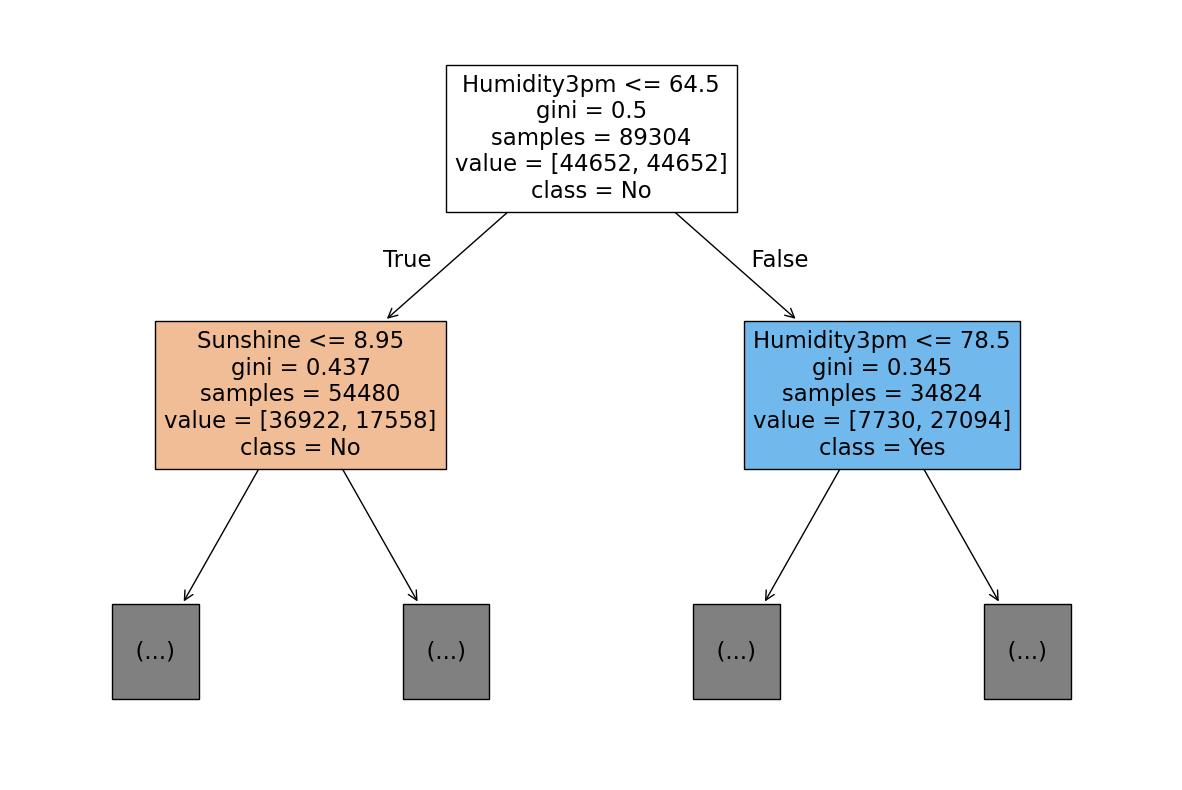

In [364]:
plt.figure(figsize=(15,10))
plot_tree(
    modelo_dt_con_balanceo_opt,
    max_depth=1,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.show()

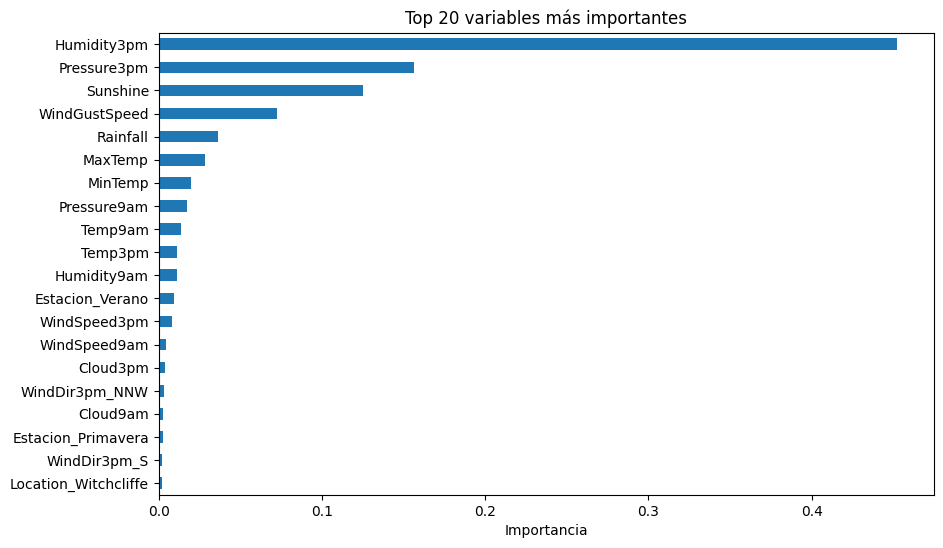

In [365]:
importancias = pd.Series(
    modelo_dt_con_balanceo_opt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(20).plot(kind="barh")

plt.xlabel("Importancia")
plt.title("Top 20 variables más importantes")
plt.gca().invert_yaxis()

plt.show()



## 5.2.0 - Random Forest

Random Forest cargado desde disco
Mejores hiperparametros:
n_estimators: 100
max_depth: 10
min_samples_split: 2
min_samples_leaf: 1
criterion: gini


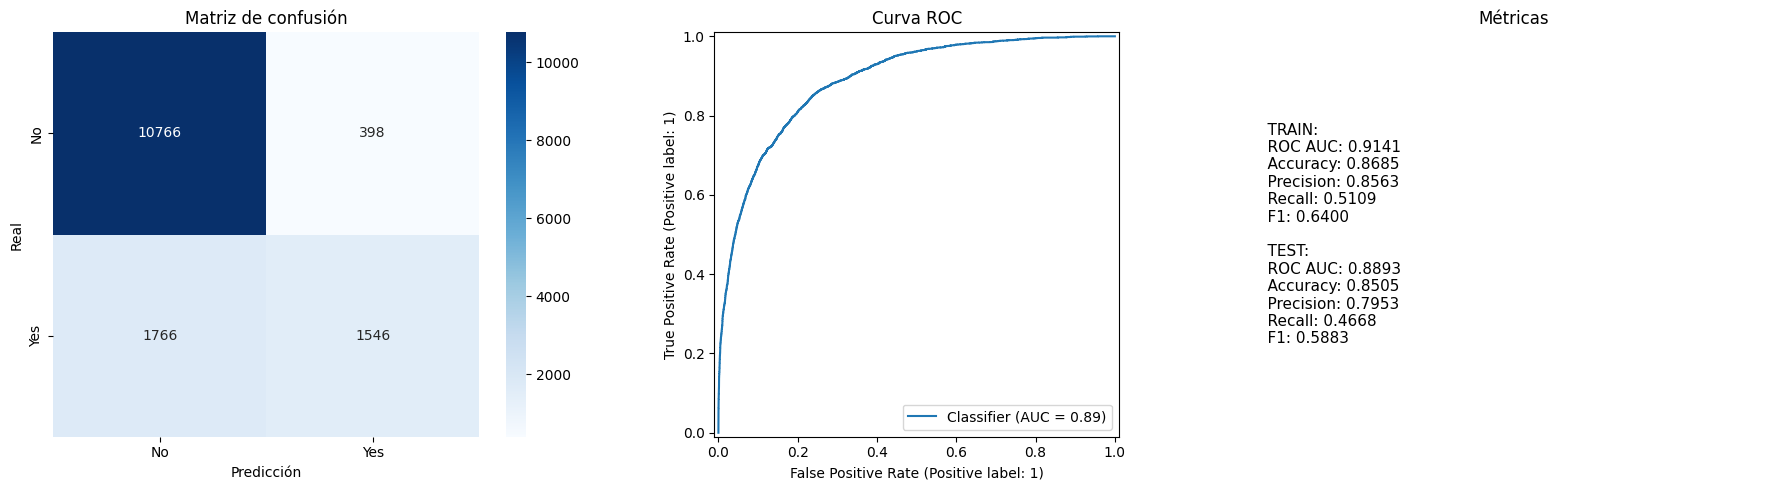

In [366]:
RUTA_RF = "modelos/random_forest.joblib"

if os.path.exists(RUTA_RF):
    modelo_rf_opt = joblib.load(RUTA_RF)
    print("Random Forest cargado desde disco")

    params = modelo_rf_opt.get_params()
    print("Mejores hiperparametros:")

    print(f"n_estimators: {params['n_estimators']}")
    print(f"max_depth: {params['max_depth']}")
    print(f"min_samples_split: {params['min_samples_split']}")
    print(f"min_samples_leaf: {params['min_samples_leaf']}")
    print(f"criterion: {params['criterion']}")


else:
    modelo_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    param_grid_rf = {
        "criterion": ["gini"],
        "n_estimators": [100, 200],
        "max_depth": [5, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 5]
    }

    modelo_rf_opt = entrenar_modelo(
        modelo_rf,
        param_grid_rf,
        X_train,
        y_train
    )

    joblib.dump(modelo_rf_opt, RUTA_RF)
    print("Random Forest entrenado y guardado")

evaluar_modelo(modelo_rf_opt, X_train, X_test, y_train, y_test)

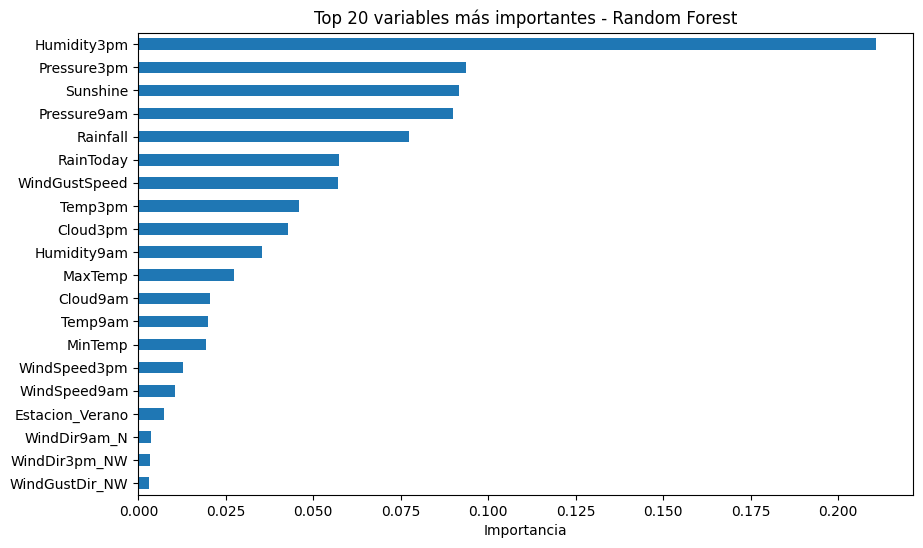

In [367]:
importancias_rf = pd.Series(
    modelo_rf_opt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importancias_rf.head(20).sort_values().plot(kind="barh")
plt.xlabel("Importancia")
plt.title("Top 20 variables más importantes - Random Forest")
plt.show()

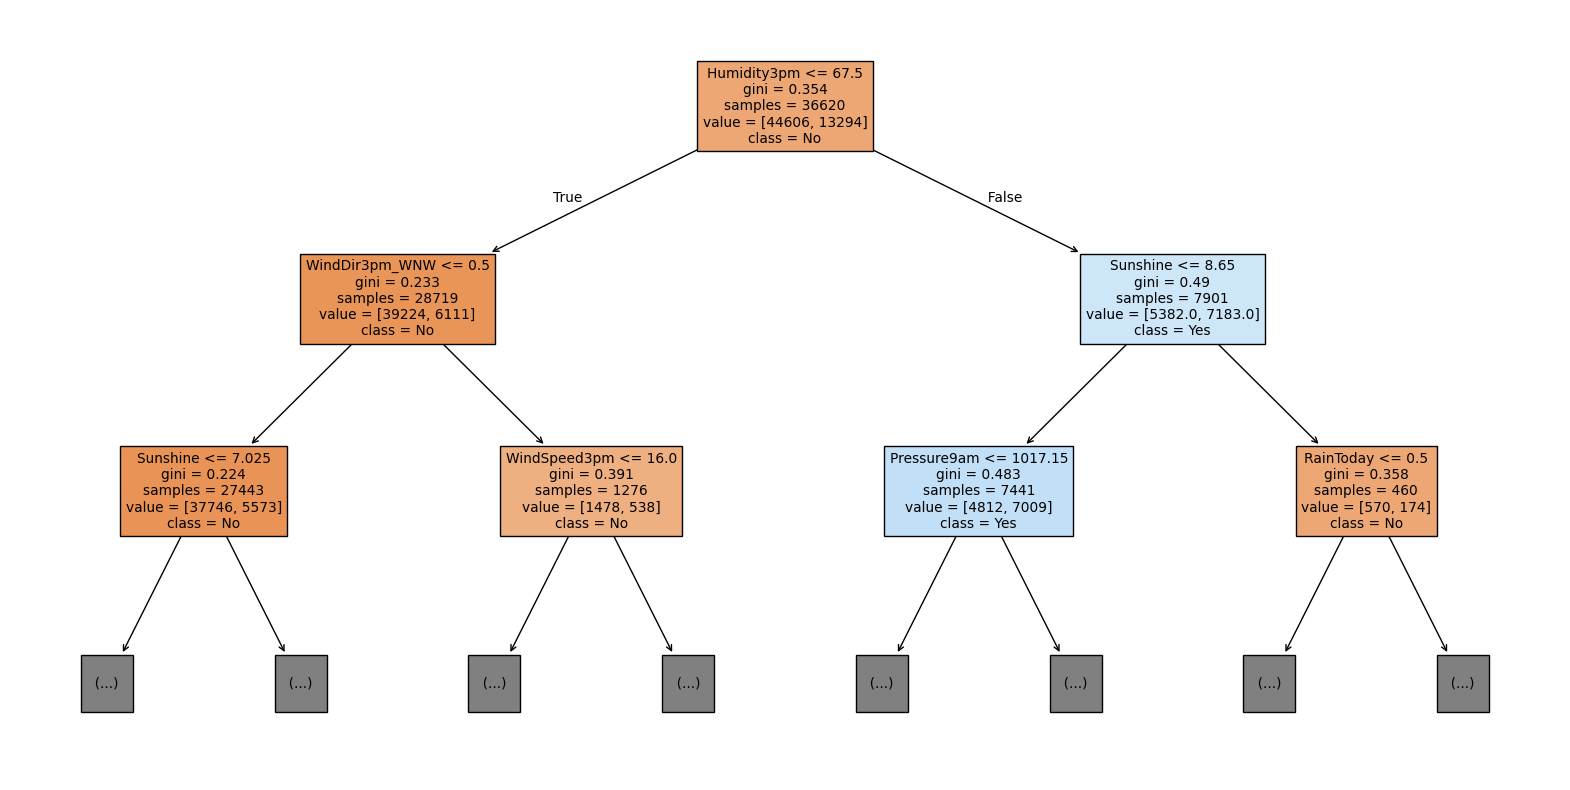

In [368]:
arbol = modelo_rf_opt.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    arbol,
    max_depth=2,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.show()

## 5.2.1 - Random Forest con balanceo de clases

Random Forest balanceado cargado desde disco
Mejores hiperparametros:
n_estimators: 200
max_depth: 10
min_samples_split: 100
min_samples_leaf: 75
criterion: gini


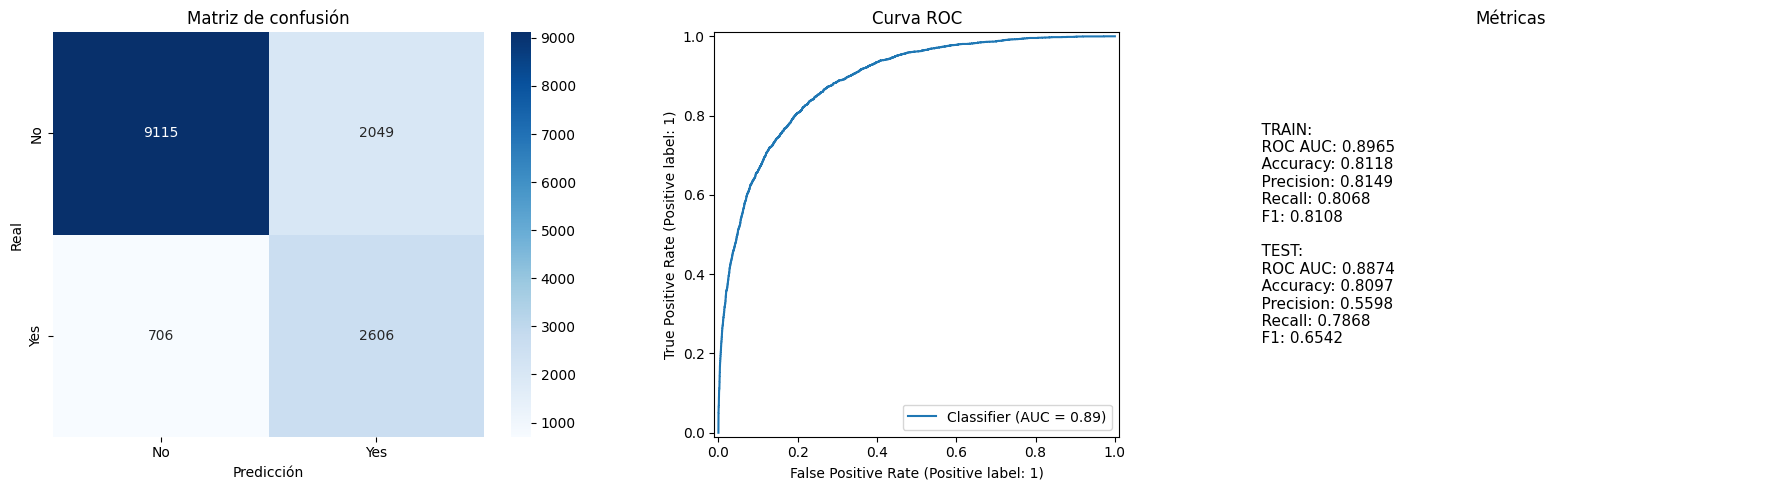

In [369]:
RUTA_RF_BAL = "modelos/random_forest_balanceado.joblib"

if os.path.exists(RUTA_RF_BAL):
    modelo_rf_opt_balanceado = joblib.load(RUTA_RF_BAL)
    print("Random Forest balanceado cargado desde disco")

    params = modelo_rf_opt_balanceado.get_params()
    print("Mejores hiperparametros:")

    print(f"n_estimators: {params['n_estimators']}")
    print(f"max_depth: {params['max_depth']}")
    print(f"min_samples_split: {params['min_samples_split']}")
    print(f"min_samples_leaf: {params['min_samples_leaf']}")
    print(f"criterion: {params['criterion']}")

else:
    modelo_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    param_grid_rf = {
        "criterion": ["gini"],
        "n_estimators": [100, 200],
        "max_depth": [5, 10],
        "min_samples_split": [100, 125, 150],
        "min_samples_leaf": [75, 100]
    }

    modelo_rf_opt_balanceado = entrenar_modelo(
        modelo_rf,
        param_grid_rf,
        X_train_bal,
        y_train_bal
    )

    joblib.dump(modelo_rf_opt_balanceado, RUTA_RF_BAL)
    print("Random Forest balanceado entrenado y guardado")

evaluar_modelo(
    modelo_rf_opt_balanceado,
    X_train_bal,
    X_test,
    y_train_bal,
    y_test
)

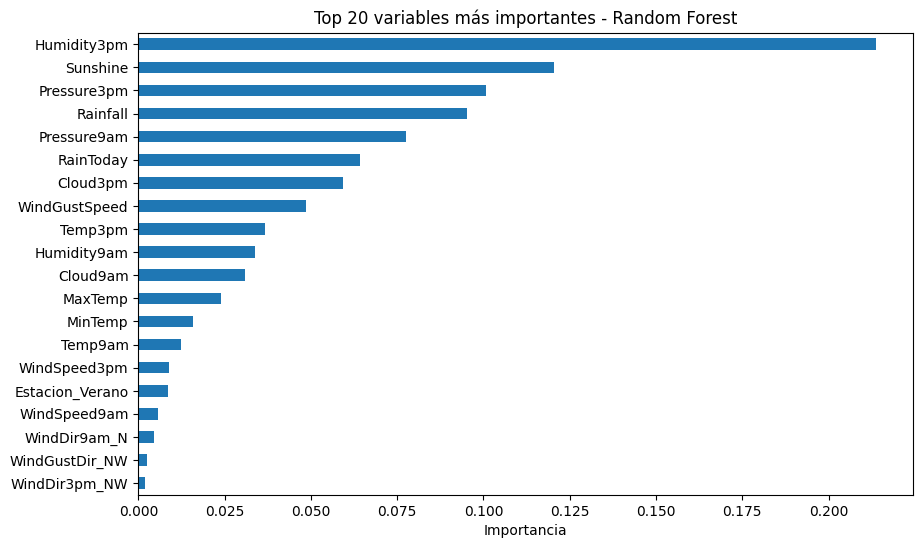

In [370]:
importancias_rf = pd.Series(
    modelo_rf_opt_balanceado.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias_rf.head(20).sort_values().plot(kind="barh")
plt.xlabel("Importancia")
plt.title("Top 20 variables más importantes - Random Forest")
plt.show()

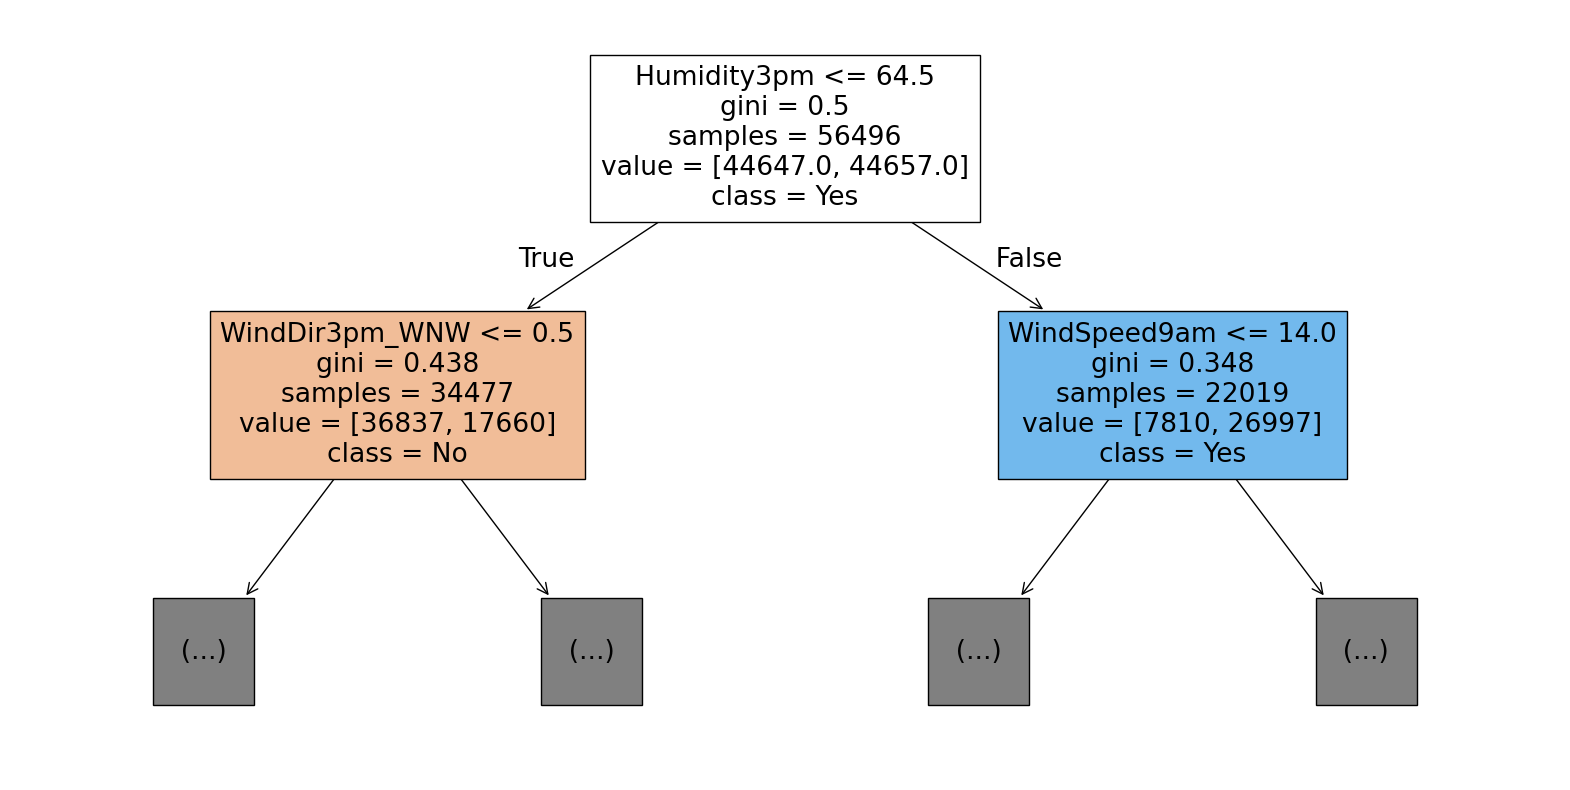

In [371]:
arbol = modelo_rf_opt_balanceado.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    arbol,
    max_depth=1,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.show()

## 5.3.0 - XGBoost

XGBoost cargado desde disco
Mejores hiperparametros:
n_estimators: 200
max_depth: 5
learning_rate: 0.1
subsample: 0.8
colsample_bytree: 0.8


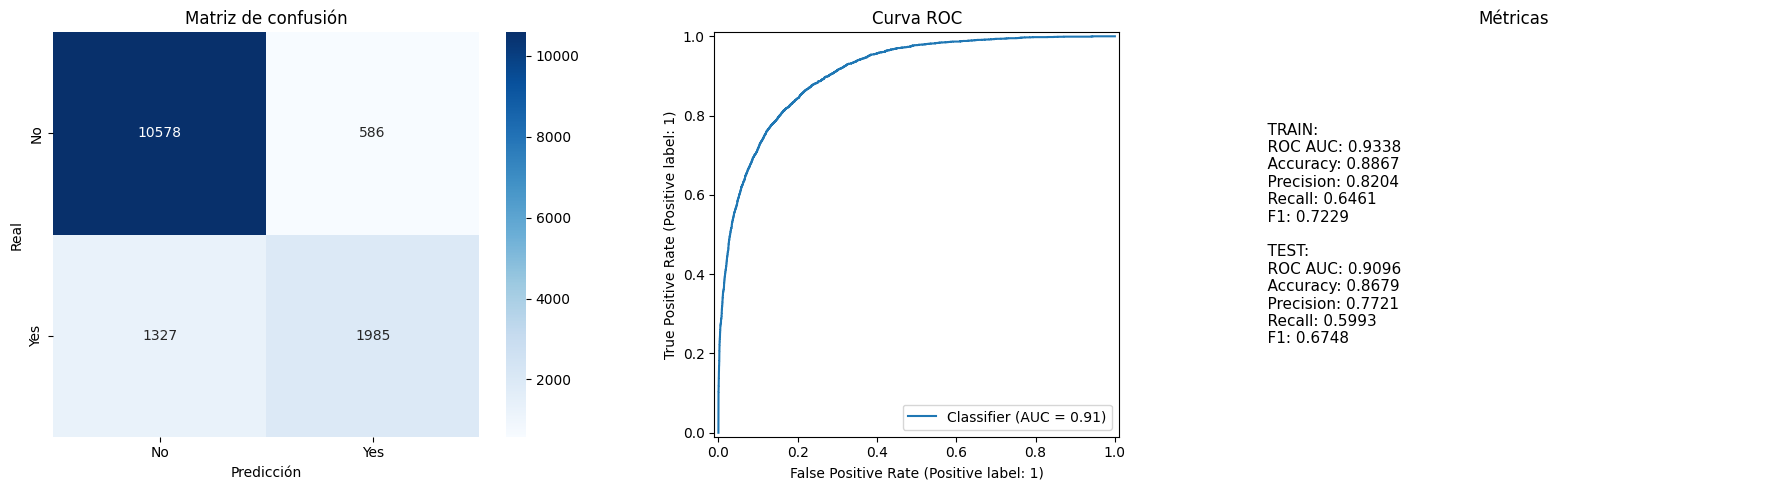

In [372]:
RUTA_XGB = "modelos/xgboost.joblib"

if os.path.exists(RUTA_XGB):
    modelo_xgb_opt = joblib.load(RUTA_XGB)
    print("XGBoost cargado desde disco")

    params = modelo_xgb_opt.get_params()
    print("Mejores hiperparametros:")

    print(f"n_estimators: {params['n_estimators']}")
    print(f"max_depth: {params['max_depth']}")
    print(f"learning_rate: {params['learning_rate']}")
    print(f"subsample: {params['subsample']}")
    print(f"colsample_bytree: {params['colsample_bytree']}")
else:
    modelo_xgb = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    param_grid_xgb = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    modelo_xgb_opt = entrenar_modelo(
        modelo_xgb,
        param_grid_xgb,
        X_train,
        y_train
    )

    joblib.dump(modelo_xgb_opt, RUTA_XGB)
    print("XGBoost entrenado y guardado")

evaluar_modelo(modelo_xgb_opt, X_train, X_test, y_train, y_test)

RainToday               0.123503
Humidity3pm             0.097513
Rainfall                0.030398
Estacion_Verano         0.027788
Sunshine                0.027266
WindGustSpeed           0.025710
Pressure3pm             0.024978
Cloud3pm                0.021978
Location_Witchcliffe    0.016179
WindDir9am_NNE          0.015691
Location_Brisbane       0.015523
WindDir3pm_NW           0.015047
WindDir9am_N            0.014112
Location_Ballarat       0.013381
Location_GoldCoast      0.013360
WindDir3pm_WNW          0.012722
Location_Perth          0.012670
Pressure9am             0.012095
WindDir3pm_NNW          0.012056
WindDir3pm_S            0.011864
dtype: float32


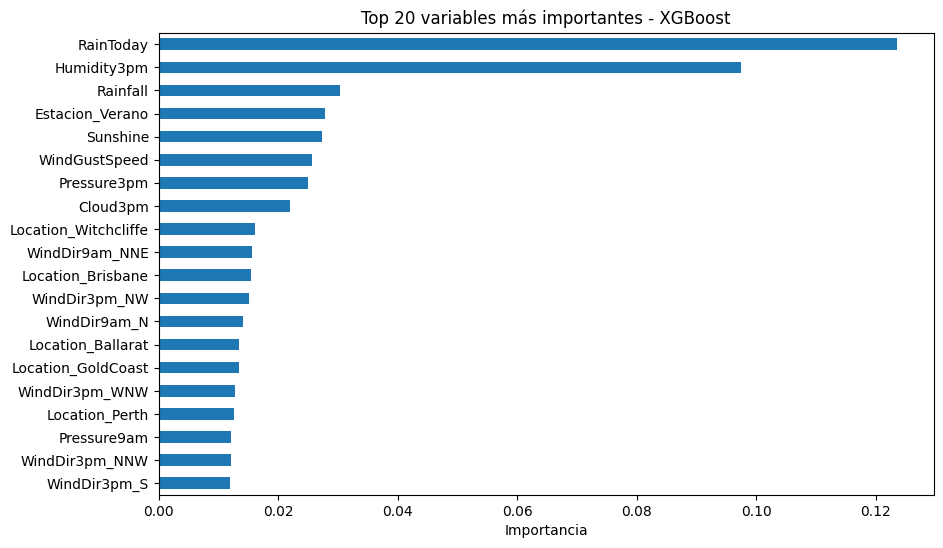

In [373]:
importancias = pd.Series(
    modelo_xgb_opt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias.head(20))

plt.figure(figsize=(10,6))
importancias.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 variables más importantes - XGBoost")
plt.xlabel("Importancia")
plt.show()

## 5.3.1 - XGBoost con balanceo de clases

XGBoost balanceado cargado desde disco
Mejores hiperparametros:
n_estimators: 200
max_depth: 5
learning_rate: 0.1
subsample: 0.8
colsample_bytree: 1.0


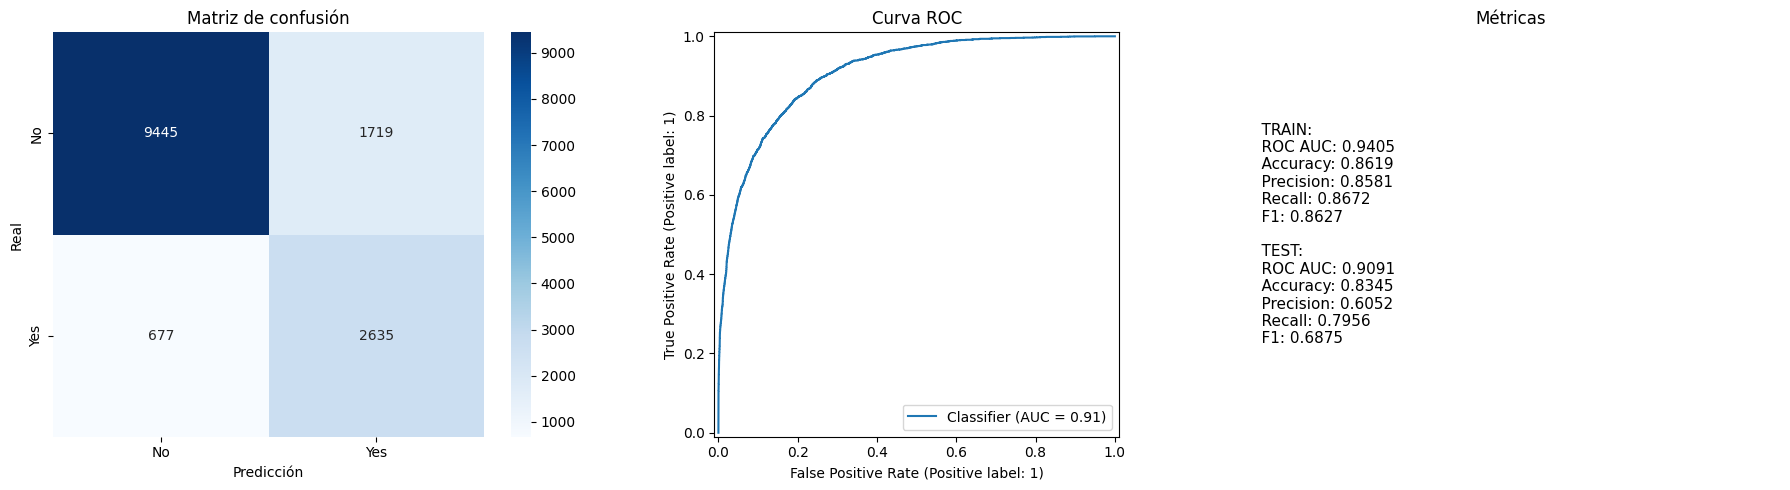

In [374]:
RUTA_XGB_BAL = "modelos/xgboost_balanceado.joblib"

if os.path.exists(RUTA_XGB_BAL):
    modelo_xgb_balanceado_opt = joblib.load(RUTA_XGB_BAL)
    print("XGBoost balanceado cargado desde disco")

    params = modelo_xgb_balanceado_opt.get_params()
    print("Mejores hiperparametros:")

    print(f"n_estimators: {params['n_estimators']}")
    print(f"max_depth: {params['max_depth']}")
    print(f"learning_rate: {params['learning_rate']}")
    print(f"subsample: {params['subsample']}")
    print(f"colsample_bytree: {params['colsample_bytree']}")

else:
    modelo_xgb_balanceado = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    param_grid_xgb = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    modelo_xgb_balanceado_opt = entrenar_modelo(
        modelo_xgb_balanceado,
        param_grid_xgb,
        X_train_bal,
        y_train_bal
    )

    joblib.dump(modelo_xgb_balanceado_opt, RUTA_XGB_BAL)
    print("XGBoost balanceado entrenado y guardado")

evaluar_modelo(
    modelo_xgb_balanceado_opt,
    X_train_bal,
    X_test,
    y_train_bal,
    y_test
)

Humidity3pm             0.102587
Estacion_Verano         0.035434
Sunshine                0.033232
Pressure3pm             0.032192
WindGustSpeed           0.031925
WindDir3pm_NW           0.027311
Rainfall                0.026253
WindDir3pm_WNW          0.019493
Location_Brisbane       0.019362
WindDir9am_NNE          0.017783
WindDir3pm_N            0.016612
WindDir9am_N            0.015670
WindDir3pm_NNW          0.015429
Location_Townsville     0.015379
Cloud3pm                0.014514
WindDir3pm_SSE          0.014143
Location_Perth          0.013565
Location_GoldCoast      0.013491
Location_SalmonGums     0.013395
Location_Witchcliffe    0.013291
dtype: float32


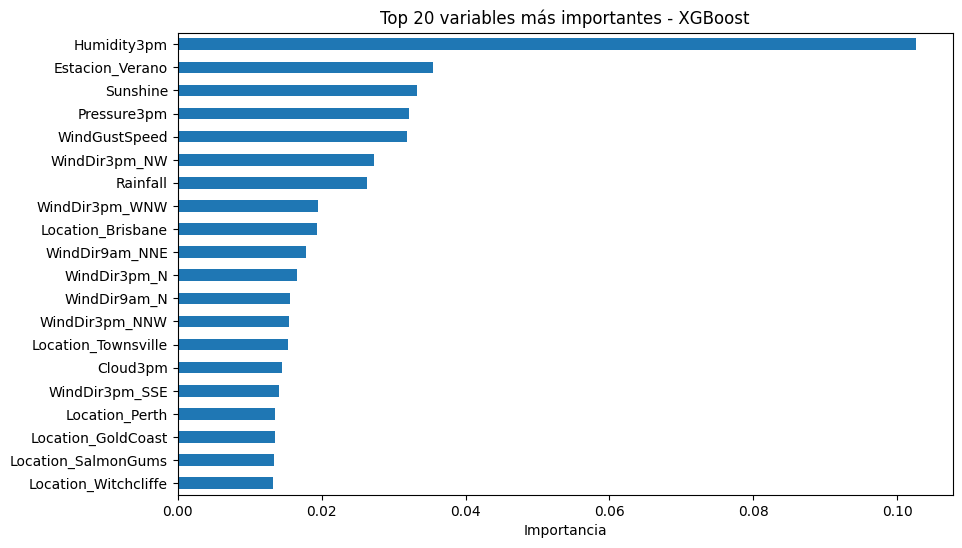

In [375]:
importancias = pd.Series(
    modelo_xgb_balanceado_opt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias.head(20))

plt.figure(figsize=(10,6))
importancias.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 variables más importantes - XGBoost")
plt.xlabel("Importancia")
plt.show()

#6 - Comparación de modelos

In [376]:
def evaluar_modelo_y_obtener_metricas(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [377]:
resultados_comparacion = pd.DataFrame([
    evaluar_modelo_y_obtener_metricas("DT sin balanceo", modelo_dt_opt, X_test, y_test),
    evaluar_modelo_y_obtener_metricas("DT balanceado", modelo_dt_con_balanceo_opt, X_test, y_test),

    evaluar_modelo_y_obtener_metricas("RF sin balanceo", modelo_rf_opt, X_test, y_test),
    evaluar_modelo_y_obtener_metricas("RF balanceado", modelo_rf_opt_balanceado, X_test, y_test),

    evaluar_modelo_y_obtener_metricas("XGB sin balanceo", modelo_xgb_opt, X_test, y_test),
    evaluar_modelo_y_obtener_metricas("XGB balanceado", modelo_xgb_balanceado_opt, X_test, y_test),
])

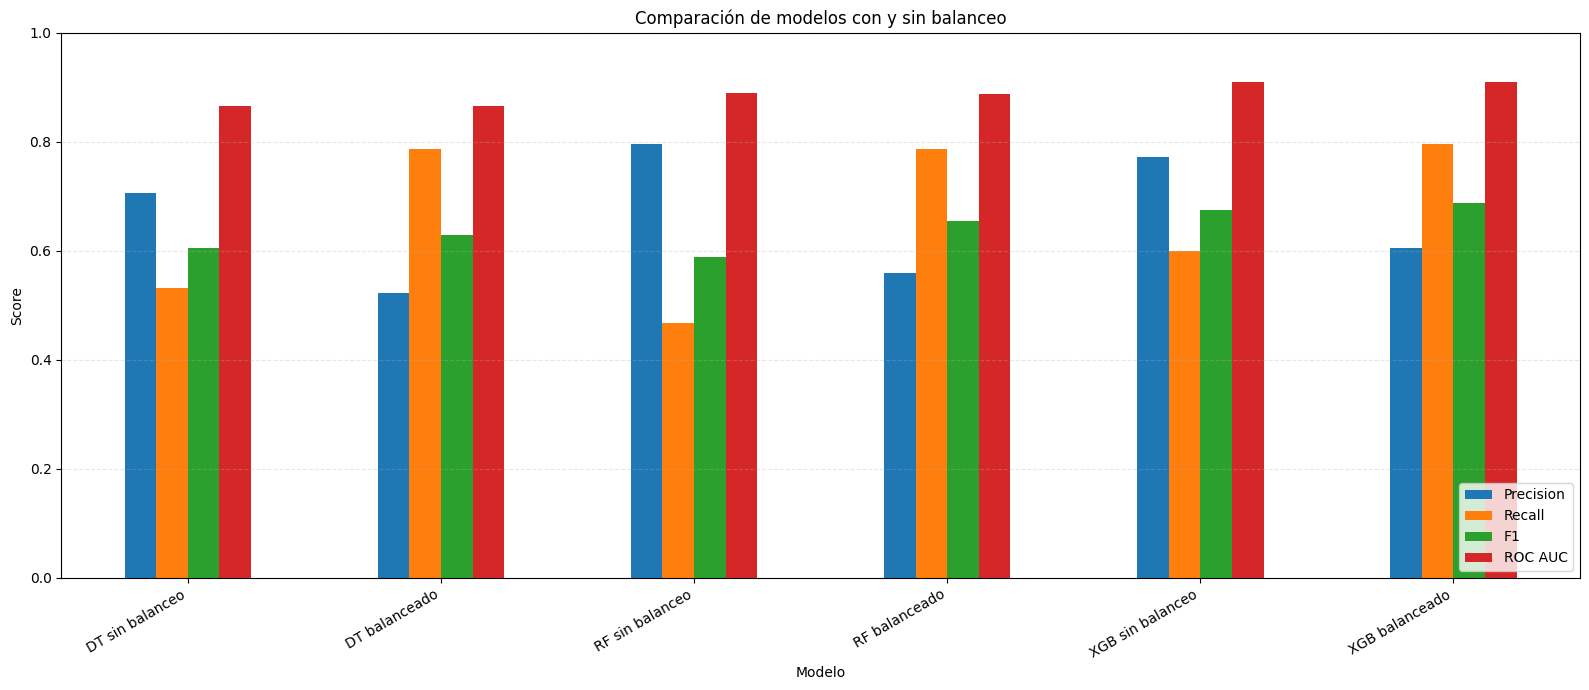

In [378]:
df_plot = resultados_comparacion.set_index("Modelo")[["Precision", "Recall", "F1", "ROC AUC"]]

df_plot.plot(kind="bar", figsize=(16,7))

plt.title("Comparación de modelos con y sin balanceo")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [379]:
resultados = pd.DataFrame([
    evaluar_modelo_y_obtener_metricas("Decision Tree balanceado", modelo_dt_con_balanceo_opt, X_test, y_test),
    evaluar_modelo_y_obtener_metricas("Random Forest balanceado", modelo_rf_opt_balanceado, X_test, y_test),
    evaluar_modelo_y_obtener_metricas("XGBoost balanceado", modelo_xgb_balanceado_opt, X_test, y_test)
])

resultados

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC,TN,FP,FN,TP
0,Decision Tree balanceado,0.787027,0.523006,0.785930,0.628061,0.866485,8790,2374,709,2603
1,Random Forest balanceado,0.809685,0.559828,0.786836,0.654199,0.887446,9115,2049,706,2606
2,XGBoost balanceado,0.834485,0.605191,0.795592,0.687451,0.909127,9445,1719,677,2635


<Figure size 640x480 with 0 Axes>

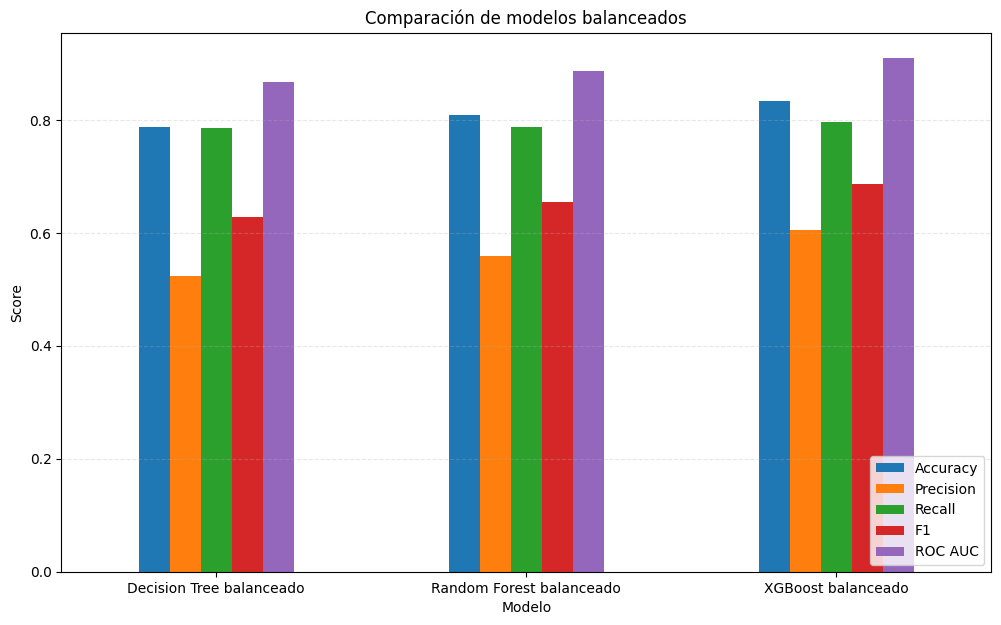

In [380]:
df_plot = resultados.set_index("Modelo")[["Accuracy","Precision", "Recall", "F1", "ROC AUC"]]

plt.figure()

df_plot.plot(kind="bar", figsize=(12,7))

plt.title("Comparación de modelos balanceados")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

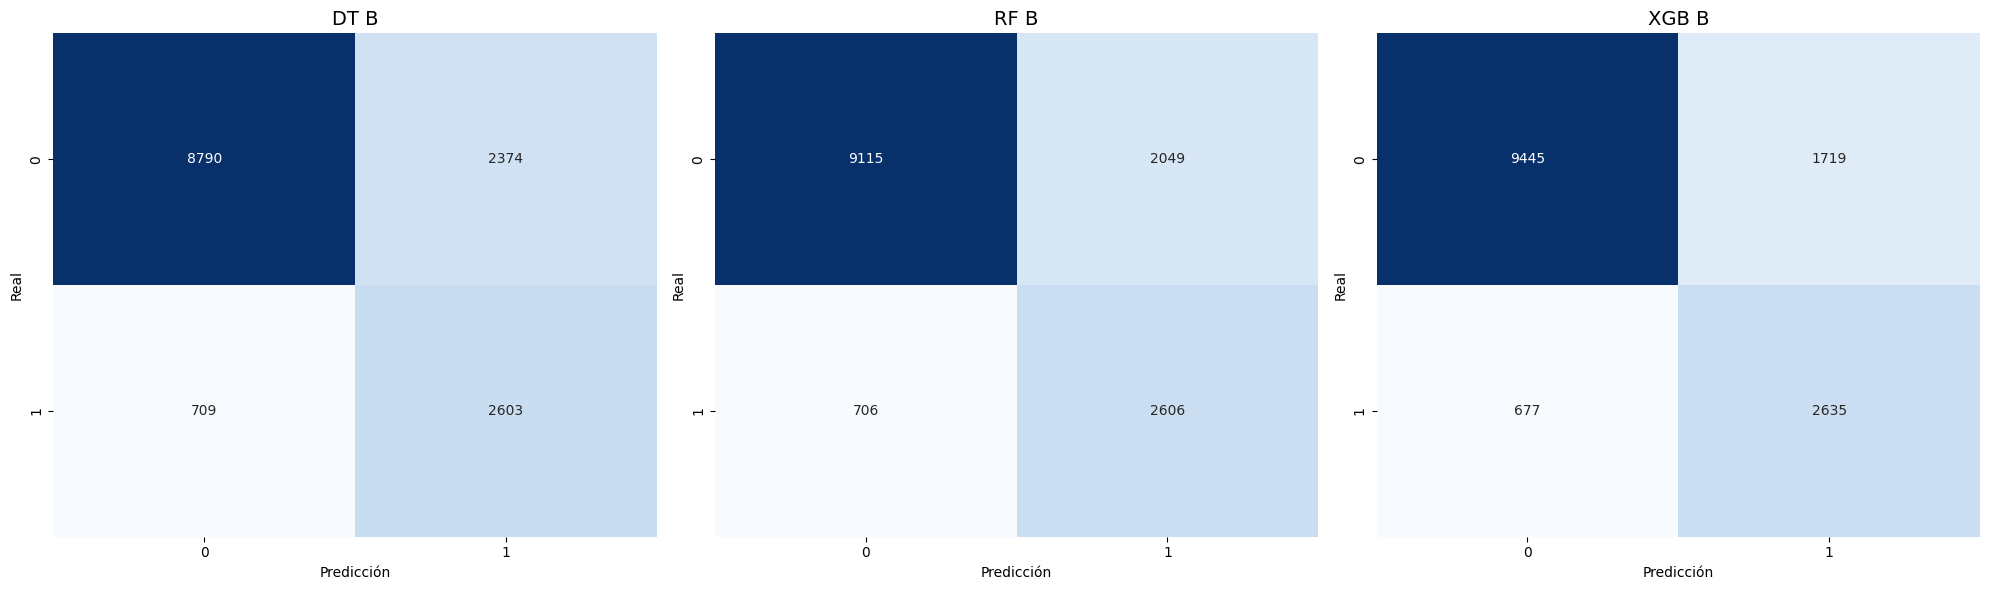

In [381]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))

modelos = [
    ("DT B", modelo_dt_con_balanceo_opt),
    ("RF B", modelo_rf_opt_balanceado),
    ("XGB B", modelo_xgb_balanceado_opt)
]

for i, (nombre, modelo) in enumerate(modelos):
    cm = confusion_matrix(y_test, modelo.predict(X_test))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        cbar=False
    )

    axes[i].set_title(nombre, fontsize=14)
    axes[i].set_xlabel("Predicción")
    axes[i].set_ylabel("Real")

plt.tight_layout()
plt.show()

# 7 - Conclusión

Finalizando este trabajo, cuyo objetivo fue predecir si lloverá o no al día siguiente en Australia a partir de datos meteorológicos del día actual, concluimos que el modelo más idóneo entre los evaluados es XGBoost.

Esta elección se basa en que presenta el mejor desempeño en función de los objetivos planteados, particularmente en la reducción de falsos negativos (FN), es decir, los casos en los que el modelo predice que no lloverá cuando en realidad sí lo hace. En este contexto, se prioriza el recall, ya que resulta más crítico detectar correctamente los eventos de lluvia.

El modelo final alcanza una accuracy de aproximadamente 83%, acompañado de un 79% de recall, lo cual resulta especialmente relevante para este problema, donde se prioriza la correcta detección de eventos de lluvia. Además, se acepta como compromiso un aumento en los falsos positivos (predecir lluvia cuando no ocurre), dado que se considera menos grave que no anticipar un evento de lluvia real.